# Exploratory Data Analysis


In [1]:
!pip install pandas matplotlib seaborn openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import os
import glob
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

root_path = Path(os.getcwd()).parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path / "src"))

from utils import TAG_INFO, THRESHOLDS

In [3]:
""" Import the complete dataset """

df = pd.read_excel('../data/raw/data_11-03_10-04.xlsx', sheet_name='Sheet1')

# Change the starting point of our data. Start where we data from all features
df["timestamp"]     = pd.to_datetime(df["timestamp"])
df                  = df.sort_values("timestamp").reset_index(drop=True)
first_complete_idx  = df.notna().all(axis=1).idxmax()
df_complete         = df.iloc[first_complete_idx:].reset_index(drop=True)

Univariate Analysis — Summary Statistics for Continuous Sensors

In [4]:
continuous_cols = ["PT-901", "PT-902", "PT-903",
                   "TT-901", "TT-902", "TT-903", "TT-904",
                   "FT-201", "FT-801", "FT-901",
                   "VSD-901_CORRENT", "VSD-901_POWER", "VSD-901_RPM", "VSD-901_SPEED"]

summary = df_complete[continuous_cols].describe().T
summary.columns = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
summary["unit"] = [TAG_INFO[col]["unit"] for col in summary.index]
summary["label"] = [TAG_INFO[col]["label"] for col in summary.index]
summary = summary[["label", "unit", "count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

summary

,label,unit,count,mean,std,min,25%,50%,75%,max
PT-901,Gas line inlet vacuum pressure,bar,39175.0,-0.681261,0.248792,-1.025101e+00,-0.833261,-0.721137,-0.551866,0.088325
PT-902,Gas line outlet vacuum pressure,bar,39175.0,0.014293,0.011896,-1.381654e-02,0.006221,0.011357,0.020399,0.050564
PT-903,Vacuum pressure in oil separator,bar,39175.0,0.066029,0.265176,-2.896296e+00,0.049769,0.081481,0.126389,0.259375
TT-901,Oil separator gas temperature,°C,39175.0,67.057679,5.048644,1.839193e+01,64.708115,67.485893,69.954422,77.083336
TT-902,Discharge 1 temperature,°C,39175.0,68.251732,4.955964,1.911893e+01,65.950523,68.630646,71.093750,78.114151
TT-903,Discharge 2 temperature,°C,39175.0,77.238675,5.234921,2.142470e+01,74.631073,77.696396,80.183918,88.395187
TT-904,Oil temperature,°C,39175.0,77.012884,5.493264,1.836480e+01,74.571396,77.468536,79.937065,87.917747
FT-201,Biogas inlet flow,Nm3/h,39175.0,621.789320,160.074010,-1.506076e+01,597.092041,652.126770,718.815094,826.258728
FT-801,Biomethane outlet flow,Nm3/h,39175.0,308.181333,87.328342,-8.000000e+02,303.588867,328.637695,352.563477,760.180603
FT-901,Exhaust gas flow,Nm3/h,39175.0,307.039863,235.333878,2.246094e+00,159.293617,266.699219,434.977219,929.003906


In [5]:
iqr_summary_rows = []

for col in continuous_cols:

    q1  = df_complete[col].quantile(0.25)
    q3  = df_complete[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask    = (df_complete[col] < lower_bound) | (df_complete[col] > upper_bound)
    n_outliers      = outlier_mask.sum()
    pct_outliers    = (n_outliers / len(df_complete)) * 100

    iqr_summary_rows.append({
        "tag":           col,
        "label":         TAG_INFO[col]["label"],
        "unit":          TAG_INFO[col]["unit"],
        "q1":            round(q1, 4),
        "q3":            round(q3, 4),
        "iqr":           round(iqr, 4),
        "lower_bound":   round(lower_bound, 4),
        "upper_bound":   round(upper_bound, 4),
        "n_outliers":    n_outliers,
        "pct_outliers":  round(pct_outliers, 2),
    })

iqr_summary = pd.DataFrame(iqr_summary_rows).set_index("tag")

iqr_summary

,label,unit,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
tag,,,,,,,,,
PT-901,Gas line inlet vacuum pressure,bar,-0.8333,-0.5519,0.2814,-1.2554,-0.1298,1445,3.69
PT-902,Gas line outlet vacuum pressure,bar,0.0062,0.0204,0.0142,-0.0150,0.0417,1324,3.38
PT-903,Vacuum pressure in oil separator,bar,0.0498,0.1264,0.0766,-0.0652,0.2413,525,1.34
TT-901,Oil separator gas temperature,°C,64.7081,69.9544,5.2463,56.8387,77.8239,579,1.48
TT-902,Discharge 1 temperature,°C,65.9505,71.0938,5.1432,58.2357,78.8086,556,1.42
TT-903,Discharge 2 temperature,°C,74.6311,80.1839,5.5528,66.3018,88.5132,549,1.40
TT-904,Oil temperature,°C,74.5714,79.9371,5.3657,66.5229,87.9856,621,1.59
FT-201,Biogas inlet flow,Nm3/h,597.0920,718.8151,121.7231,414.5075,901.3997,3900,9.96
FT-801,Biomethane outlet flow,Nm3/h,303.5889,352.5635,48.9746,230.1270,426.0254,3089,7.89


## Univariate Analysis

### Pressure Sensors

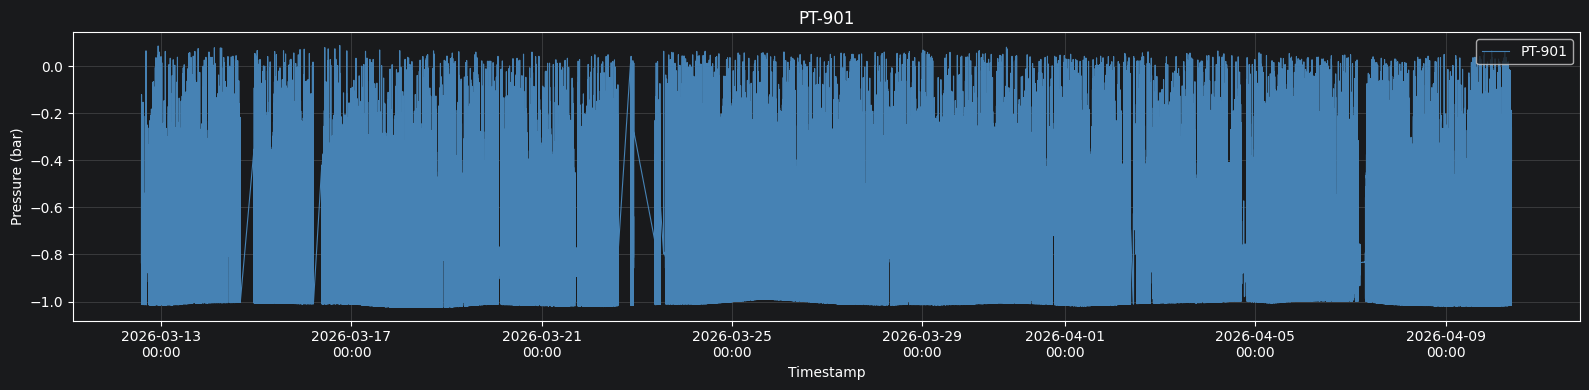

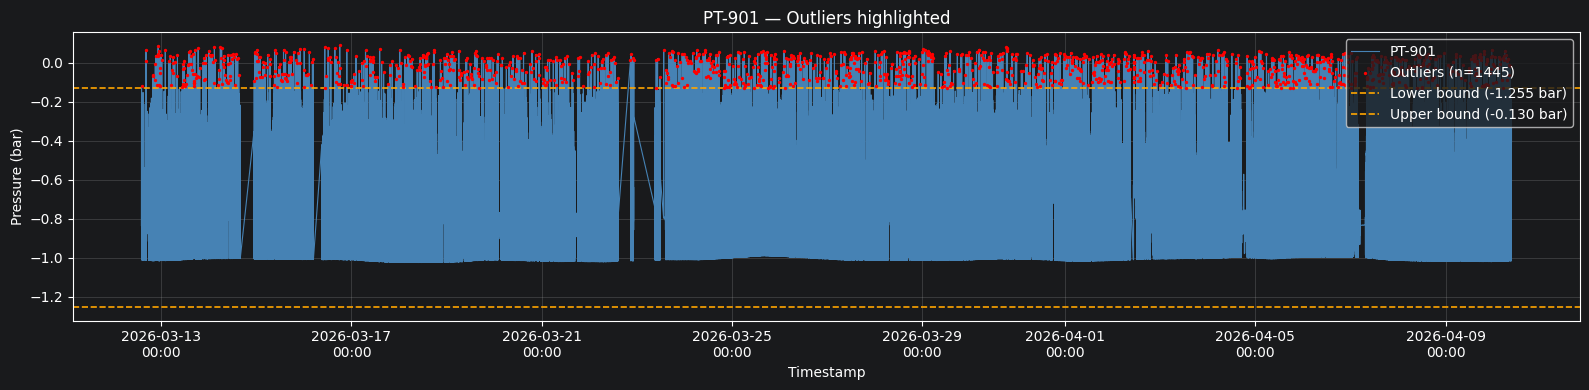

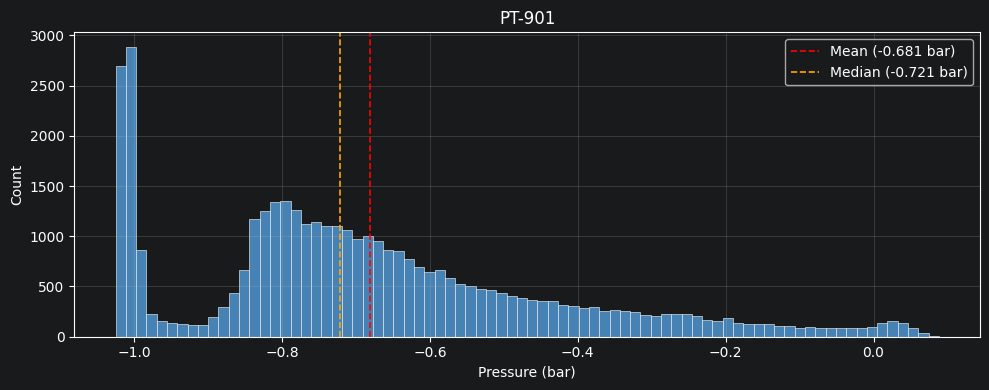

In [6]:
""" Univariate Time Series — PT-901 """
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["PT-901"],
    linewidth=0.8,
    color="steelblue",
    label="PT-901"
)

ax.set_title("PT-901")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Pressure (bar)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Outlier Highlight — PT-901 """

pt901_q1  = df_complete["PT-901"].quantile(0.25)
pt901_q3  = df_complete["PT-901"].quantile(0.75)
pt901_iqr = pt901_q3 - pt901_q1

pt901_lower_bound = pt901_q1 - 1.5 * pt901_iqr
pt901_upper_bound = pt901_q3 + 1.5 * pt901_iqr

pt901_outlier_mask    = (df_complete["PT-901"] < pt901_lower_bound) | (df_complete["PT-901"] > pt901_upper_bound)
pt901_outliers        = df_complete[pt901_outlier_mask]
pt901_normal          = df_complete[~pt901_outlier_mask]

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["PT-901"],
    linewidth=0.8,
    color="steelblue",
    label="PT-901"
)

ax.scatter(
    pt901_outliers["timestamp"],
    pt901_outliers["PT-901"],
    color="red",
    s=2,
    zorder=5,
    label=f"Outliers (n={len(pt901_outliers)})"
)

ax.axhline(
    y=pt901_lower_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Lower bound ({pt901_lower_bound:.3f} bar)"
)

ax.axhline(
    y=pt901_upper_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Upper bound ({pt901_upper_bound:.3f} bar)"
)

ax.set_title("PT-901 — Outliers highlighted")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Pressure (bar)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Distribution — PT-901  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["PT-901"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["PT-901"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['PT-901'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["PT-901"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['PT-901'].median():.3f} bar)"
)

ax.set_title("PT-901")
ax.set_xlabel("Pressure (bar)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


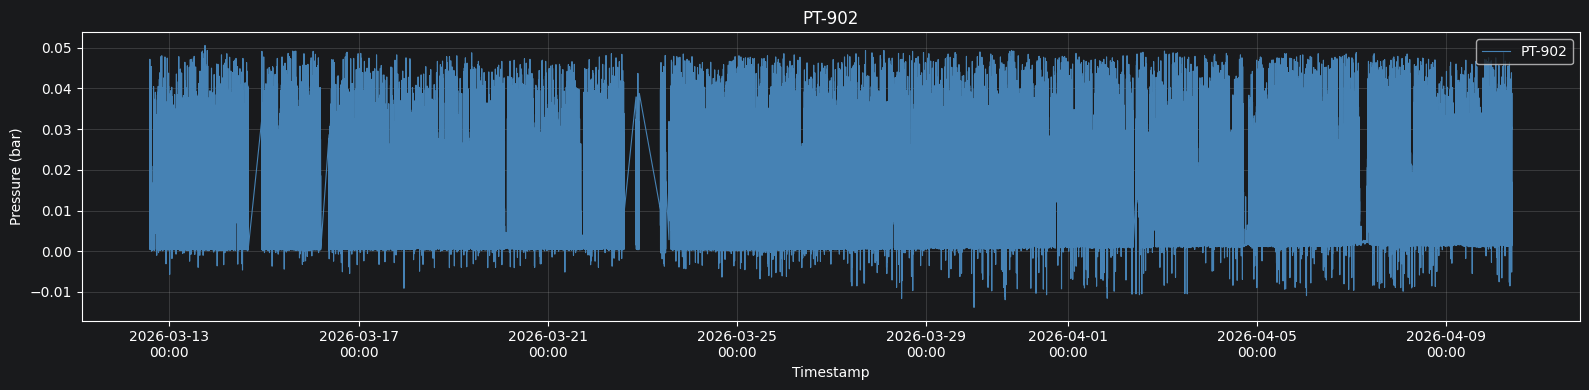

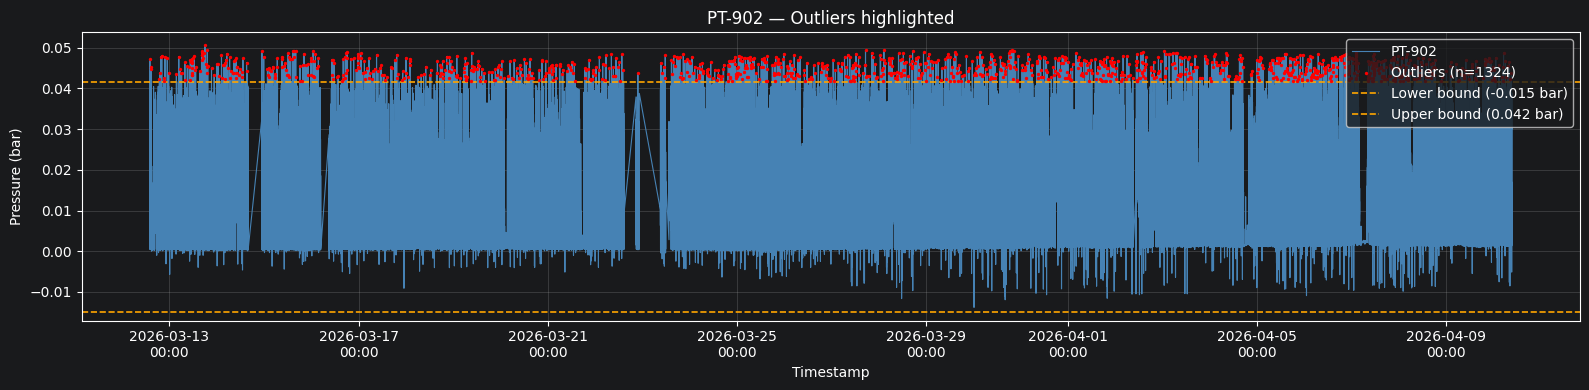

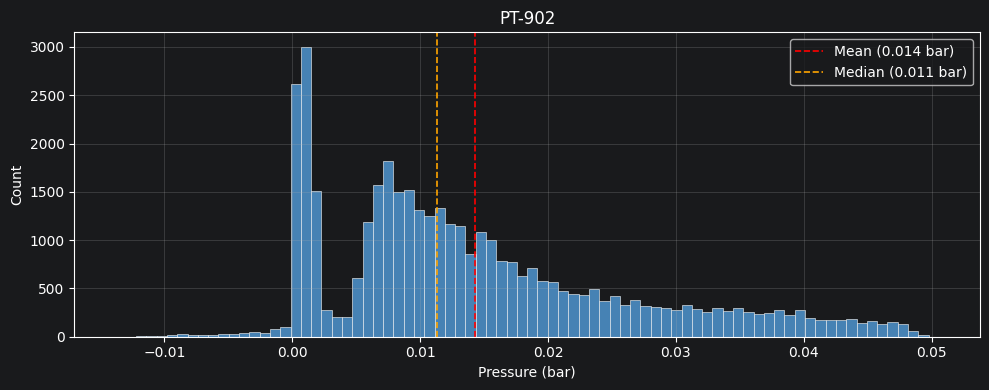

In [7]:
""" Univariate Time Series — PT-902 """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["PT-902"],
    linewidth=0.8,
    color="steelblue",
    label="PT-902"
)

ax.set_title("PT-902")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Pressure (bar)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Outlier Highlight — PT-902 """

pt902_q1  = df_complete["PT-902"].quantile(0.25)
pt902_q3  = df_complete["PT-902"].quantile(0.75)
pt902_iqr = pt902_q3 - pt902_q1

pt902_lower_bound = pt902_q1 - 1.5 * pt902_iqr
pt902_upper_bound = pt902_q3 + 1.5 * pt902_iqr

pt902_outlier_mask    = (df_complete["PT-902"] < pt902_lower_bound) | (df_complete["PT-902"] > pt902_upper_bound)
pt902_outliers        = df_complete[pt902_outlier_mask]
pt902_normal          = df_complete[~pt902_outlier_mask]

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["PT-902"],
    linewidth=0.8,
    color="steelblue",
    label="PT-902"
)

ax.scatter(
    pt902_outliers["timestamp"],
    pt902_outliers["PT-902"],
    color="red",
    s=2,
    zorder=5,
    label=f"Outliers (n={len(pt902_outliers)})"
)

ax.axhline(
    y=pt902_lower_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Lower bound ({pt902_lower_bound:.3f} bar)"
)

ax.axhline(
    y=pt902_upper_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Upper bound ({pt902_upper_bound:.3f} bar)"
)

ax.set_title("PT-902 — Outliers highlighted")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Pressure (bar)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Distribution — PT-902  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["PT-902"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["PT-902"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['PT-902'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["PT-902"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['PT-902'].median():.3f} bar)"
)

ax.set_title("PT-902")
ax.set_xlabel("Pressure (bar)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


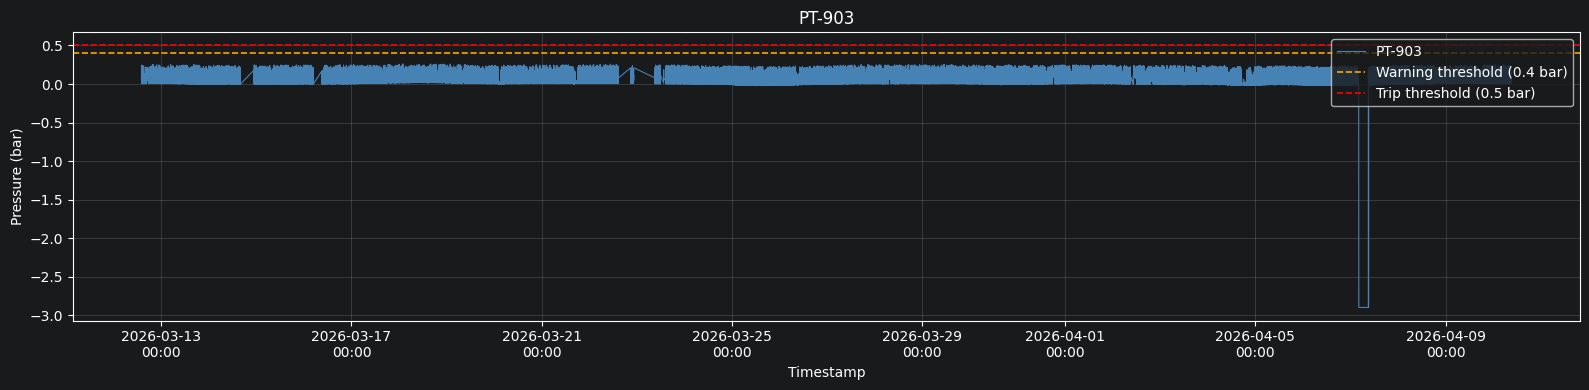

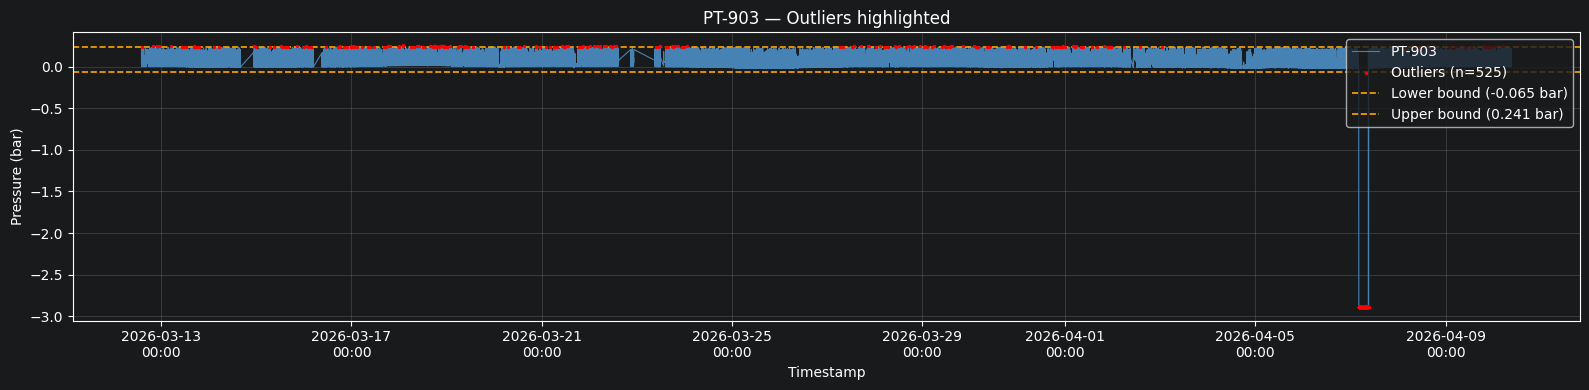

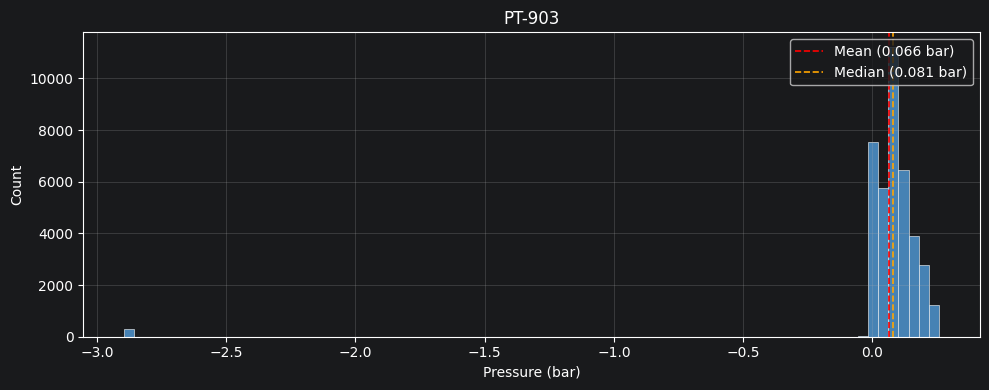

In [8]:
""" Univariate Time Series — PT-903 """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["PT-903"],
    linewidth=0.8,
    color="steelblue",
    label="PT-903"
)

ax.axhline(
    y=THRESHOLDS["PT-903"]["warning"],
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Warning threshold ({THRESHOLDS['PT-903']['warning']} bar)"
)

ax.axhline(
    y=THRESHOLDS["PT-903"]["trip"],
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Trip threshold ({THRESHOLDS['PT-903']['trip']} bar)"
)

ax.set_title("PT-903")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Pressure (bar)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Outlier Highlight — PT-903 """

pt903_q1  = df_complete["PT-903"].quantile(0.25)
pt903_q3  = df_complete["PT-903"].quantile(0.75)
pt903_iqr = pt903_q3 - pt903_q1

pt903_lower_bound = pt903_q1 - 1.5 * pt903_iqr
pt903_upper_bound = pt903_q3 + 1.5 * pt903_iqr

pt903_outlier_mask    = (df_complete["PT-903"] < pt903_lower_bound) | (df_complete["PT-903"] > pt903_upper_bound)
pt903_outliers        = df_complete[pt903_outlier_mask]
pt903_normal          = df_complete[~pt903_outlier_mask]

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["PT-903"],
    linewidth=0.8,
    color="steelblue",
    label="PT-903"
)

ax.scatter(
    pt903_outliers["timestamp"],
    pt903_outliers["PT-903"],
    color="red",
    s=2,
    zorder=5,
    label=f"Outliers (n={len(pt903_outliers)})"
)

ax.axhline(
    y=pt903_lower_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Lower bound ({pt903_lower_bound:.3f} bar)"
)

ax.axhline(
    y=pt903_upper_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Upper bound ({pt903_upper_bound:.3f} bar)"
)

ax.set_title("PT-903 — Outliers highlighted")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Pressure (bar)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Distribution — PT-903  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["PT-903"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["PT-903"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['PT-903'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["PT-903"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['PT-903'].median():.3f} bar)"
)

ax.set_title("PT-903")
ax.set_xlabel("Pressure (bar)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Temperature Sensors

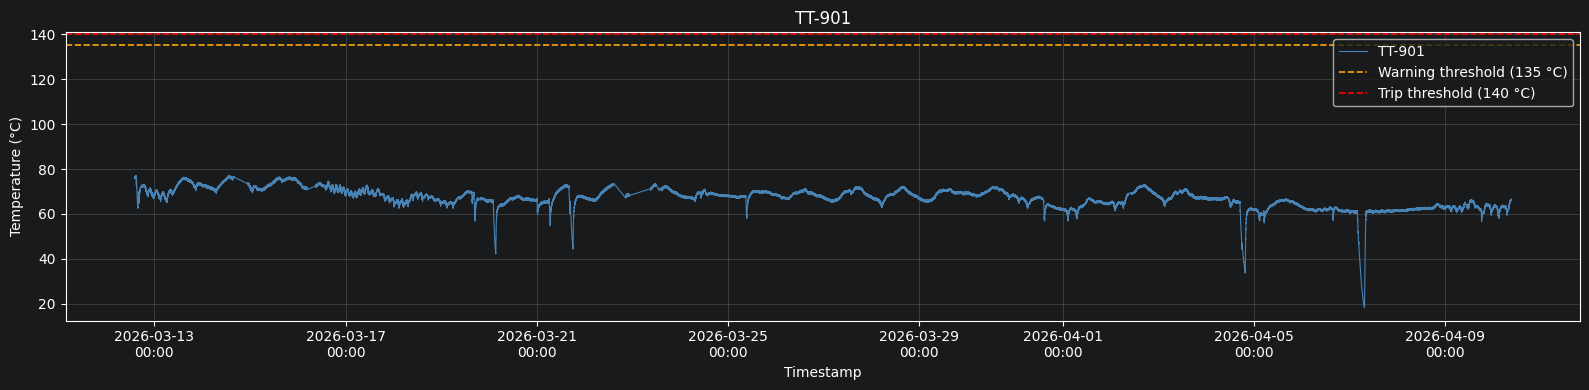

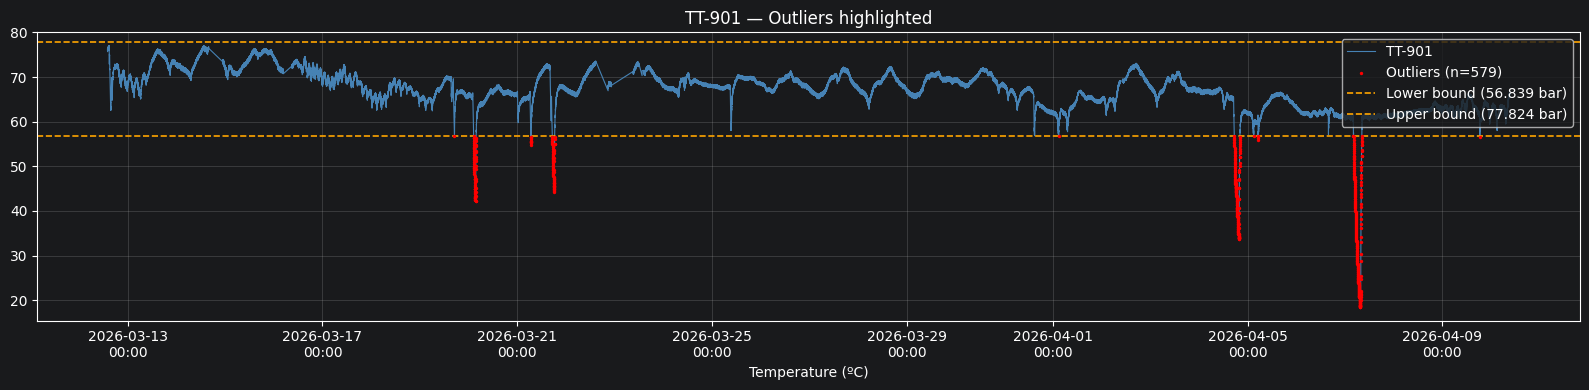

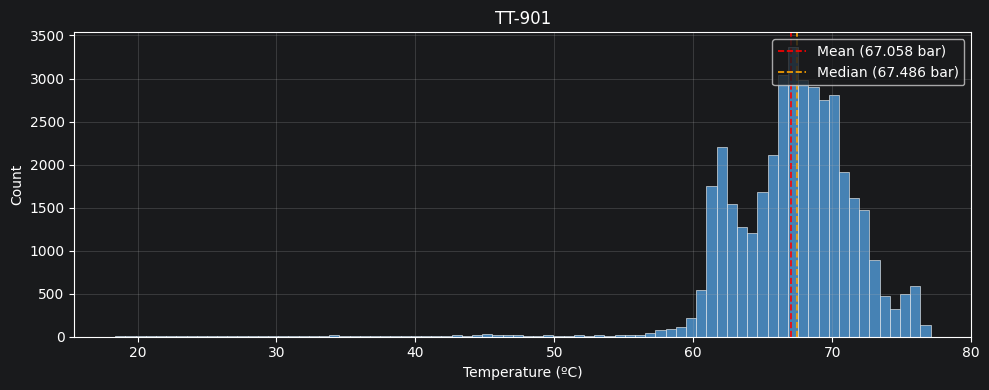

In [9]:
""" Univariate Time Series — TT-901 """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["TT-901"],
    linewidth=0.8,
    color="steelblue",
    label="TT-901"
)

ax.axhline(
    y=THRESHOLDS["TT-901"]["warning"],
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Warning threshold ({THRESHOLDS['TT-901']['warning']} °C)"
)

ax.axhline(
    y=THRESHOLDS["TT-901"]["trip"],
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Trip threshold ({THRESHOLDS['TT-901']['trip']} °C)"
)

ax.set_title("TT-901")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Outlier Highlight — TT-901 """

tt901_q1  = df_complete["TT-901"].quantile(0.25)
tt901_q3  = df_complete["TT-901"].quantile(0.75)
tt901_iqr = tt901_q3 - tt901_q1

tt901_lower_bound = tt901_q1 - 1.5 * tt901_iqr
tt901_upper_bound = tt901_q3 + 1.5 * tt901_iqr

tt901_outlier_mask    = (df_complete["TT-901"] < tt901_lower_bound) | (df_complete["TT-901"] > tt901_upper_bound)
tt901_outliers        = df_complete[tt901_outlier_mask]
tt901_normal          = df_complete[~tt901_outlier_mask]

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["TT-901"],
    linewidth=0.8,
    color="steelblue",
    label="TT-901"
)

ax.scatter(
    tt901_outliers["timestamp"],
    tt901_outliers["TT-901"],
    color="red",
    s=2,
    zorder=5,
    label=f"Outliers (n={len(tt901_outliers)})"
)

ax.axhline(
    y=tt901_lower_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Lower bound ({tt901_lower_bound:.3f} bar)"
)

ax.axhline(
    y=tt901_upper_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Upper bound ({tt901_upper_bound:.3f} bar)"
)

ax.set_title("TT-901 — Outliers highlighted")
ax.set_xlabel("Timestamp")
ax.set_xlabel("Temperature (ºC)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Distribution — TT-901  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["TT-901"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["TT-901"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['TT-901'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["TT-901"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['TT-901'].median():.3f} bar)"
)

ax.set_title("TT-901")
ax.set_xlabel("Temperature (ºC)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

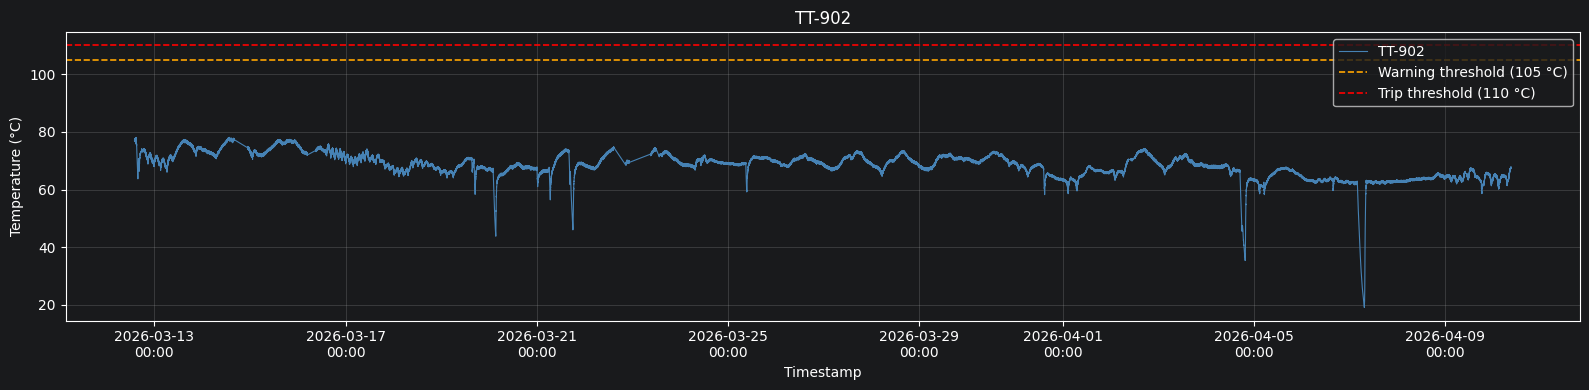

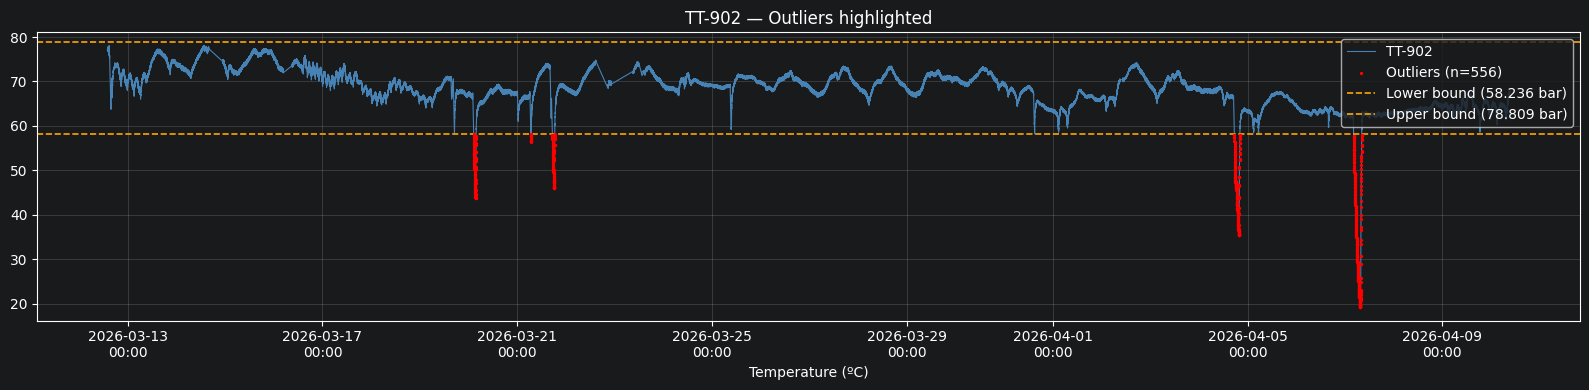

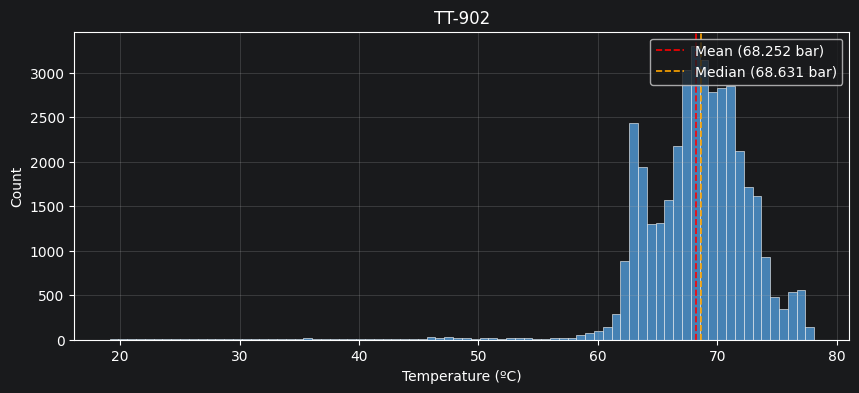

In [10]:
""" Univariate Time Series — TT-902 """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["TT-902"],
    linewidth=0.8,
    color="steelblue",
    label="TT-902"
)

ax.axhline(
    y=THRESHOLDS["TT-902"]["warning"],
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Warning threshold ({THRESHOLDS['TT-902']['warning']} °C)"
)

ax.axhline(
    y=THRESHOLDS["TT-902"]["trip"],
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Trip threshold ({THRESHOLDS['TT-902']['trip']} °C)"
)

ax.set_title("TT-902")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Outlier Highlight — TT-902 """

tt902_q1  = df_complete["TT-902"].quantile(0.25)
tt902_q3  = df_complete["TT-902"].quantile(0.75)
tt902_iqr = tt902_q3 - tt902_q1

tt902_lower_bound = tt902_q1 - 1.5 * tt902_iqr
tt902_upper_bound = tt902_q3 + 1.5 * tt902_iqr

tt902_outlier_mask    = (df_complete["TT-902"] < tt902_lower_bound) | (df_complete["TT-902"] > tt902_upper_bound)
tt902_outliers        = df_complete[tt902_outlier_mask]
tt902_normal          = df_complete[~tt902_outlier_mask]

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["TT-902"],
    linewidth=0.8,
    color="steelblue",
    label="TT-902"
)

ax.scatter(
    tt902_outliers["timestamp"],
    tt902_outliers["TT-902"],
    color="red",
    s=2,
    zorder=5,
    label=f"Outliers (n={len(tt902_outliers)})"
)

ax.axhline(
    y=tt902_lower_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Lower bound ({tt902_lower_bound:.3f} bar)"
)

ax.axhline(
    y=tt902_upper_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Upper bound ({tt902_upper_bound:.3f} bar)"
)

ax.set_title("TT-902 — Outliers highlighted")
ax.set_xlabel("Timestamp")
ax.set_xlabel("Temperature (ºC)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Distribution — TT-902  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["TT-902"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["TT-902"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['TT-902'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["TT-902"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['TT-902'].median():.3f} bar)"
)

ax.set_title("TT-902")
ax.set_xlabel("Temperature (ºC)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

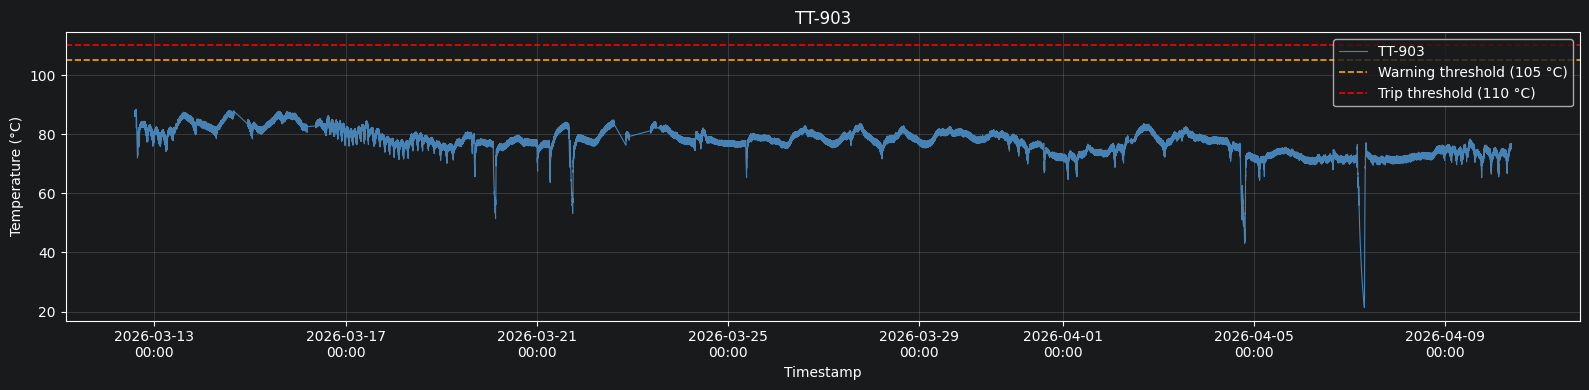

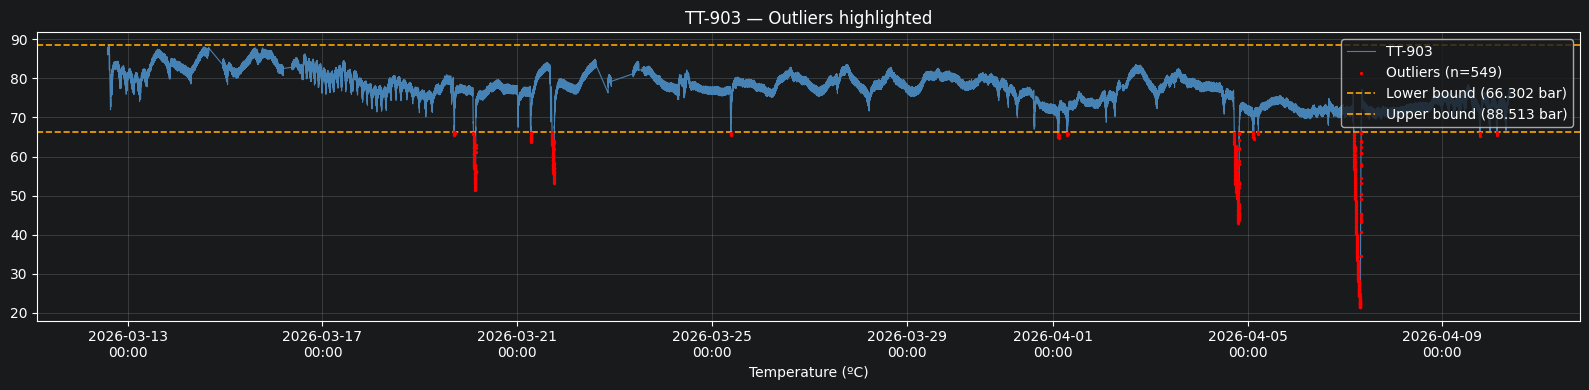

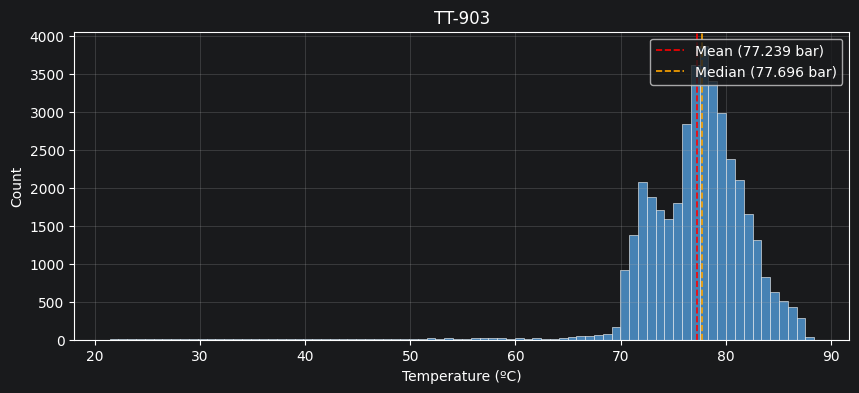

In [11]:
""" Univariate Time Series — TT-903 """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["TT-903"],
    linewidth=0.8,
    color="steelblue",
    label="TT-903"
)

ax.axhline(
    y=THRESHOLDS["TT-903"]["warning"],
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Warning threshold ({THRESHOLDS['TT-903']['warning']} °C)"
)

ax.axhline(
    y=THRESHOLDS["TT-903"]["trip"],
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Trip threshold ({THRESHOLDS['TT-903']['trip']} °C)"
)

ax.set_title("TT-903")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Outlier Highlight — TT-903 """

tt903_q1  = df_complete["TT-903"].quantile(0.25)
tt903_q3  = df_complete["TT-903"].quantile(0.75)
tt903_iqr = tt903_q3 - tt903_q1

tt903_lower_bound = tt903_q1 - 1.5 * tt903_iqr
tt903_upper_bound = tt903_q3 + 1.5 * tt903_iqr

tt903_outlier_mask    = (df_complete["TT-903"] < tt903_lower_bound) | (df_complete["TT-903"] > tt903_upper_bound)
tt903_outliers        = df_complete[tt903_outlier_mask]
tt903_normal          = df_complete[~tt903_outlier_mask]

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["TT-903"],
    linewidth=0.8,
    color="steelblue",
    label="TT-903"
)

ax.scatter(
    tt903_outliers["timestamp"],
    tt903_outliers["TT-903"],
    color="red",
    s=2,
    zorder=5,
    label=f"Outliers (n={len(tt903_outliers)})"
)

ax.axhline(
    y=tt903_lower_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Lower bound ({tt903_lower_bound:.3f} bar)"
)

ax.axhline(
    y=tt903_upper_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Upper bound ({tt903_upper_bound:.3f} bar)"
)

ax.set_title("TT-903 — Outliers highlighted")
ax.set_xlabel("Timestamp")
ax.set_xlabel("Temperature (ºC)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Distribution — TT-903  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["TT-903"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["TT-903"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['TT-903'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["TT-903"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['TT-903'].median():.3f} bar)"
)

ax.set_title("TT-903")
ax.set_xlabel("Temperature (ºC)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

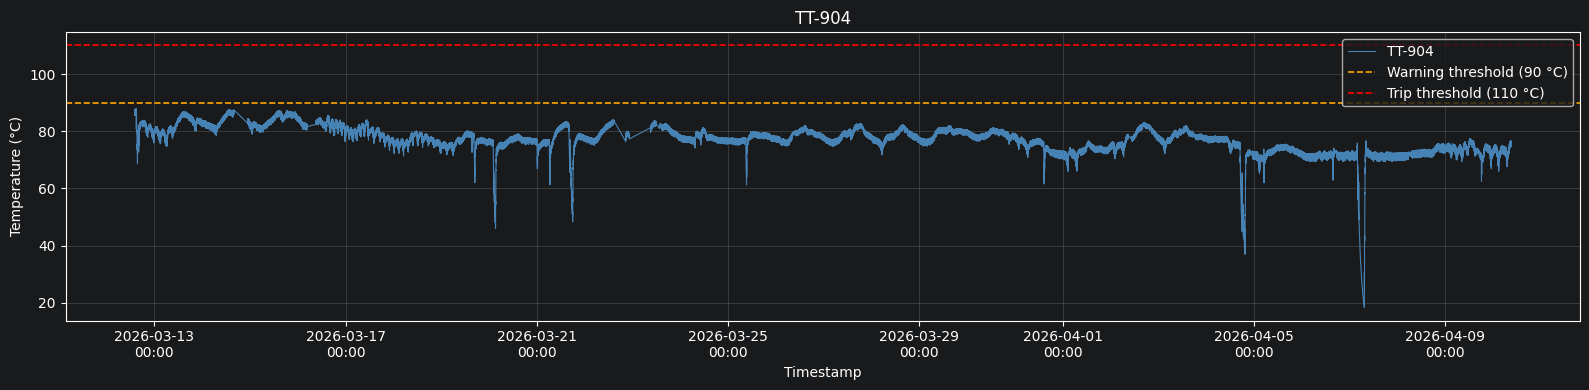

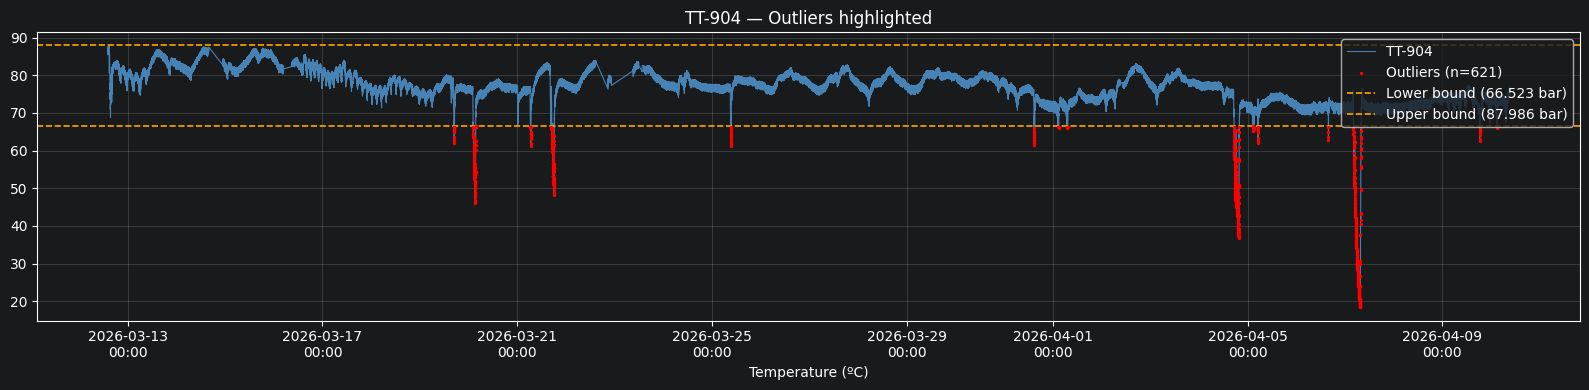

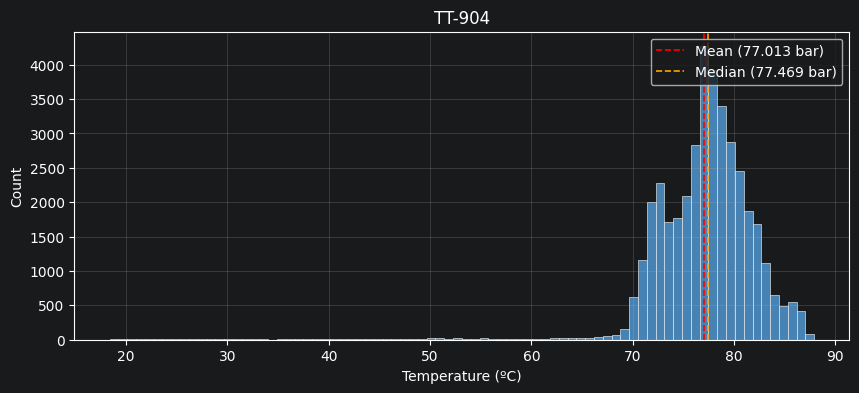

In [12]:
""" Univariate Time Series — TT-904 """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["TT-904"],
    linewidth=0.8,
    color="steelblue",
    label="TT-904"
)

ax.axhline(
    y=THRESHOLDS["TT-904"]["warning"],
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Warning threshold ({THRESHOLDS['TT-904']['warning']} °C)"
)

ax.axhline(
    y=THRESHOLDS["TT-904"]["trip"],
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Trip threshold ({THRESHOLDS['TT-904']['trip']} °C)"
)

ax.set_title("TT-904")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Outlier Highlight — TT-904 """

tt904_q1  = df_complete["TT-904"].quantile(0.25)
tt904_q3  = df_complete["TT-904"].quantile(0.75)
tt904_iqr = tt904_q3 - tt904_q1

tt904_lower_bound = tt904_q1 - 1.5 * tt904_iqr
tt904_upper_bound = tt904_q3 + 1.5 * tt904_iqr

tt904_outlier_mask    = (df_complete["TT-904"] < tt904_lower_bound) | (df_complete["TT-904"] > tt904_upper_bound)
tt904_outliers        = df_complete[tt904_outlier_mask]
tt904_normal          = df_complete[~tt904_outlier_mask]

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["TT-904"],
    linewidth=0.8,
    color="steelblue",
    label="TT-904"
)

ax.scatter(
    tt904_outliers["timestamp"],
    tt904_outliers["TT-904"],
    color="red",
    s=2,
    zorder=5,
    label=f"Outliers (n={len(tt904_outliers)})"
)

ax.axhline(
    y=tt904_lower_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Lower bound ({tt904_lower_bound:.3f} bar)"
)

ax.axhline(
    y=tt904_upper_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Upper bound ({tt904_upper_bound:.3f} bar)"
)

ax.set_title("TT-904 — Outliers highlighted")
ax.set_xlabel("Timestamp")
ax.set_xlabel("Temperature (ºC)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Distribution — TT-904  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["TT-904"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["TT-904"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['TT-904'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["TT-904"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['TT-904'].median():.3f} bar)"
)

ax.set_title("TT-904")
ax.set_xlabel("Temperature (ºC)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

### Flow Sensors

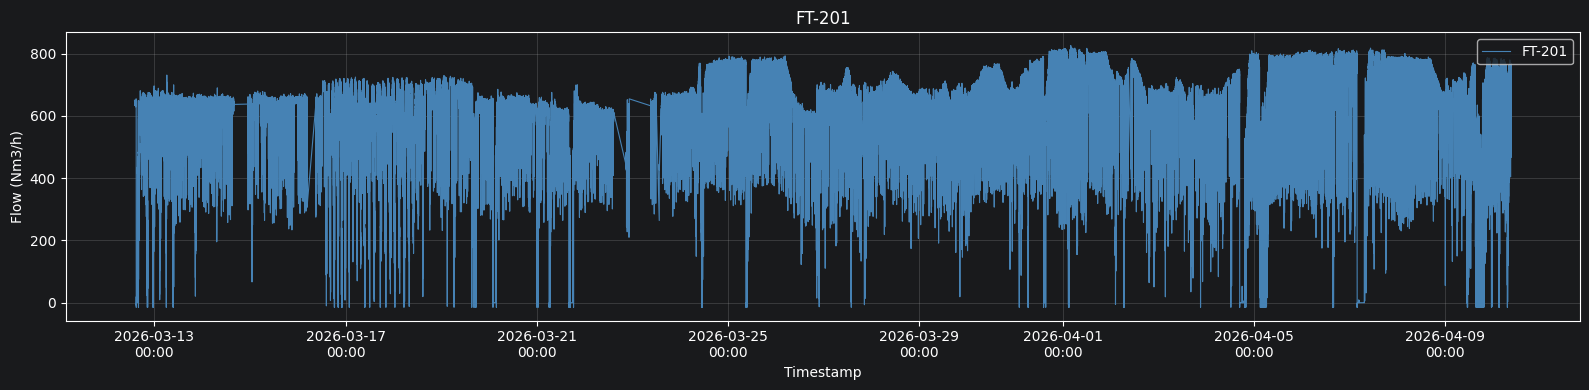

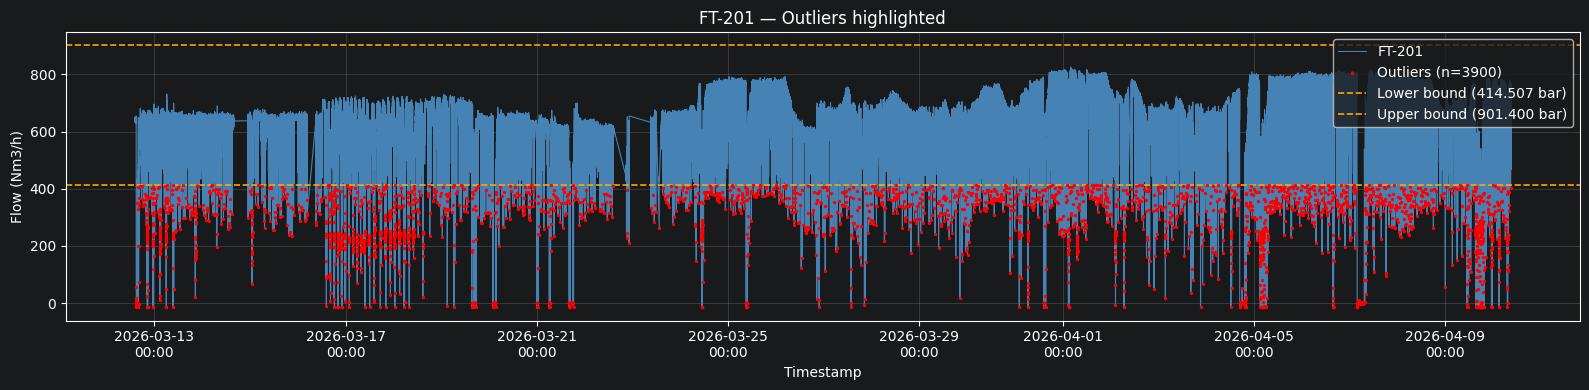

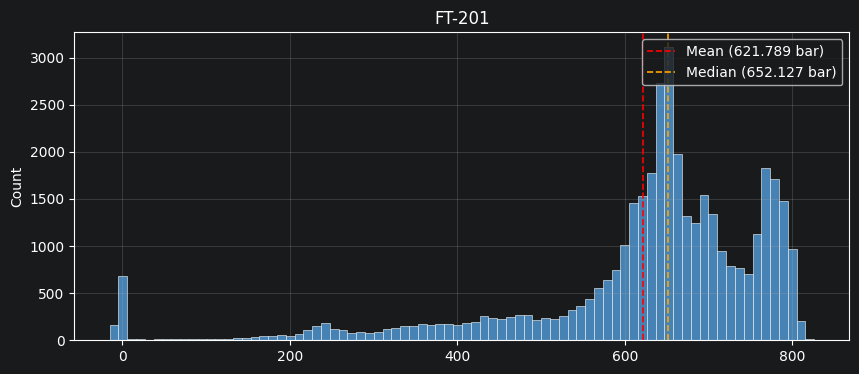

In [13]:
""" Univariate Time Series — FT-201 """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["FT-201"],
    linewidth=0.8,
    color="steelblue",
    label="FT-201"
)

ax.set_title("FT-201")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Flow (Nm3/h)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Outlier Highlight — FT-201 """

tt201_q1  = df_complete["FT-201"].quantile(0.25)
tt201_q3  = df_complete["FT-201"].quantile(0.75)
tt201_iqr = tt201_q3 - tt201_q1

tt201_lower_bound = tt201_q1 - 1.5 * tt201_iqr
tt201_upper_bound = tt201_q3 + 1.5 * tt201_iqr

tt201_outlier_mask    = (df_complete["FT-201"] < tt201_lower_bound) | (df_complete["FT-201"] > tt201_upper_bound)
tt201_outliers        = df_complete[tt201_outlier_mask]
tt201_normal          = df_complete[~tt201_outlier_mask]

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["FT-201"],
    linewidth=0.8,
    color="steelblue",
    label="FT-201"
)

ax.scatter(
    tt201_outliers["timestamp"],
    tt201_outliers["FT-201"],
    color="red",
    s=2,
    zorder=5,
    label=f"Outliers (n={len(tt201_outliers)})"
)

ax.axhline(
    y=tt201_lower_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Lower bound ({tt201_lower_bound:.3f} bar)"
)

ax.axhline(
    y=tt201_upper_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Upper bound ({tt201_upper_bound:.3f} bar)"
)

ax.set_title("FT-201 — Outliers highlighted")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Flow (Nm3/h)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Distribution — FT-201  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["FT-201"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["FT-201"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['FT-201'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["FT-201"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['FT-201'].median():.3f} bar)"
)

ax.set_title("FT-201")
ax.set_ylabel("Flow (Nm3/h)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)


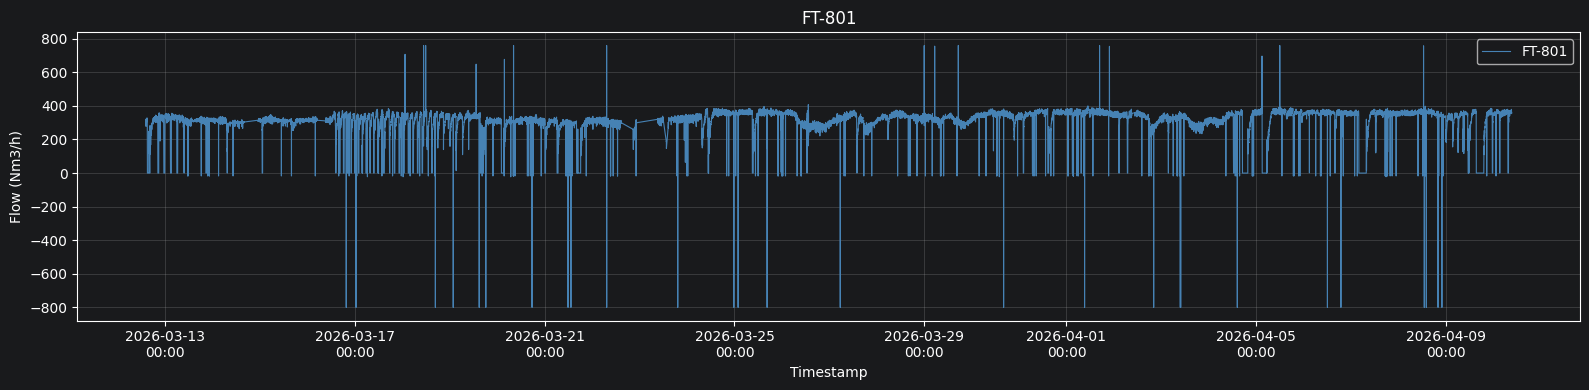

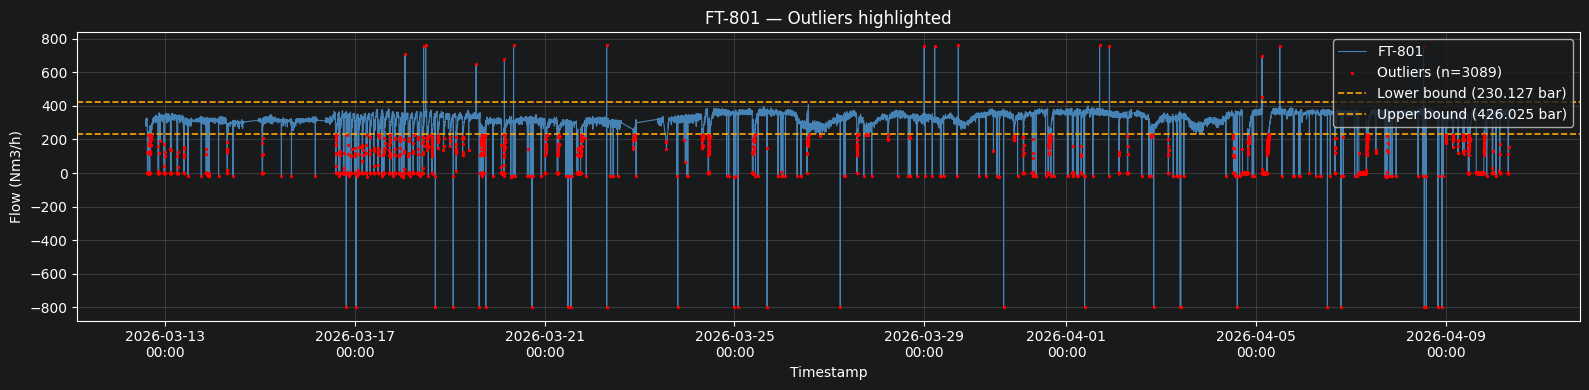

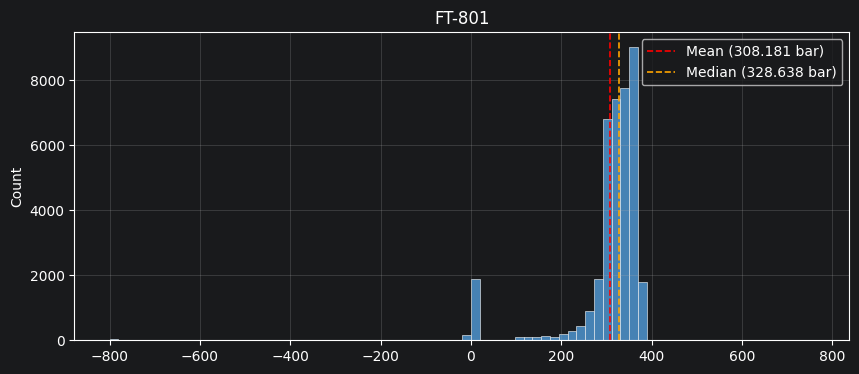

In [14]:
""" Univariate Time Series — FT-801 """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["FT-801"],
    linewidth=0.8,
    color="steelblue",
    label="FT-801"
)

ax.set_title("FT-801")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Flow (Nm3/h)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Outlier Highlight — FT-801 """

tt801_q1  = df_complete["FT-801"].quantile(0.25)
tt801_q3  = df_complete["FT-801"].quantile(0.75)
tt801_iqr = tt801_q3 - tt801_q1

tt801_lower_bound = tt801_q1 - 1.5 * tt801_iqr
tt801_upper_bound = tt801_q3 + 1.5 * tt801_iqr

tt801_outlier_mask    = (df_complete["FT-801"] < tt801_lower_bound) | (df_complete["FT-801"] > tt801_upper_bound)
tt801_outliers        = df_complete[tt801_outlier_mask]
tt801_normal          = df_complete[~tt801_outlier_mask]

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["FT-801"],
    linewidth=0.8,
    color="steelblue",
    label="FT-801"
)

ax.scatter(
    tt801_outliers["timestamp"],
    tt801_outliers["FT-801"],
    color="red",
    s=2,
    zorder=5,
    label=f"Outliers (n={len(tt801_outliers)})"
)

ax.axhline(
    y=tt801_lower_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Lower bound ({tt801_lower_bound:.3f} bar)"
)

ax.axhline(
    y=tt801_upper_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Upper bound ({tt801_upper_bound:.3f} bar)"
)

ax.set_title("FT-801 — Outliers highlighted")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Flow (Nm3/h)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Distribution — FT-801  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["FT-801"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["FT-801"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['FT-801'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["FT-801"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['FT-801'].median():.3f} bar)"
)

ax.set_title("FT-801")
ax.set_ylabel("Flow (Nm3/h)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)



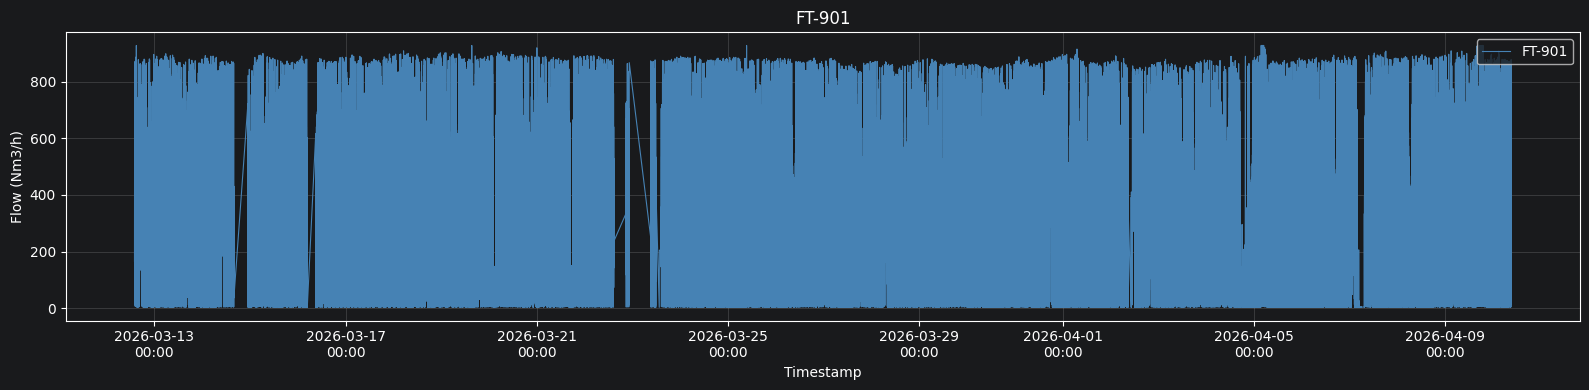

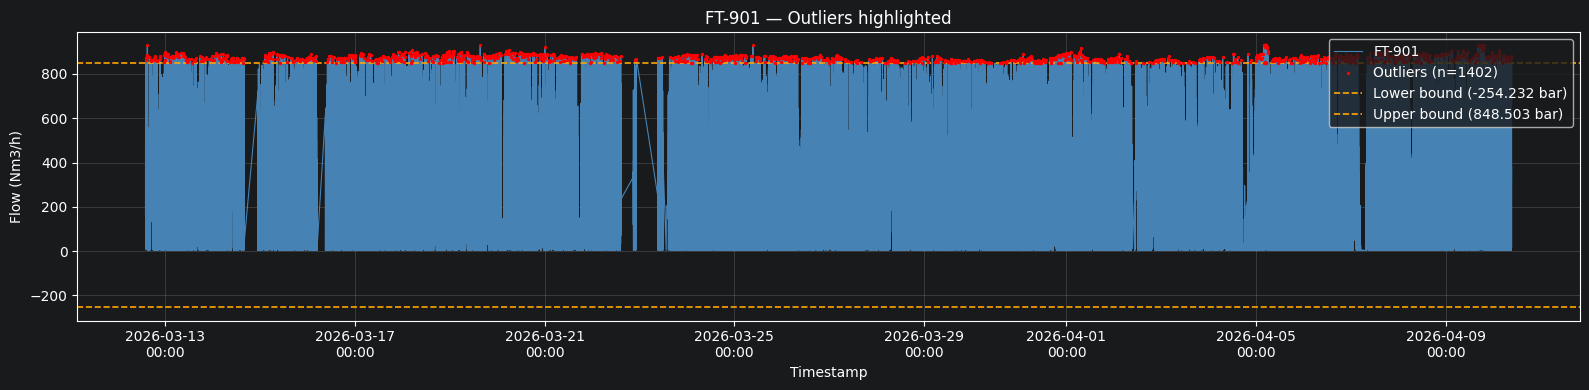

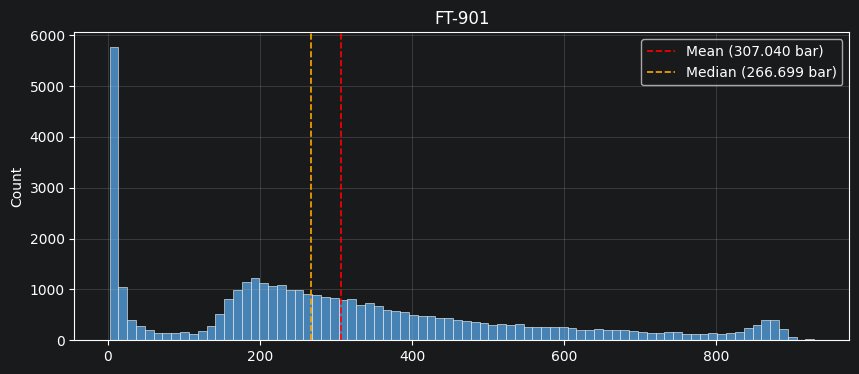

In [15]:
""" Univariate Time Series — FT-901 """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["FT-901"],
    linewidth=0.8,
    color="steelblue",
    label="FT-901"
)

ax.set_title("FT-901")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Flow (Nm3/h)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Outlier Highlight — FT-901 """

tt901_q1  = df_complete["FT-901"].quantile(0.25)
tt901_q3  = df_complete["FT-901"].quantile(0.75)
tt901_iqr = tt901_q3 - tt901_q1

tt901_lower_bound = tt901_q1 - 1.5 * tt901_iqr
tt901_upper_bound = tt901_q3 + 1.5 * tt901_iqr

tt901_outlier_mask    = (df_complete["FT-901"] < tt901_lower_bound) | (df_complete["FT-901"] > tt901_upper_bound)
tt901_outliers        = df_complete[tt901_outlier_mask]
tt901_normal          = df_complete[~tt901_outlier_mask]

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["FT-901"],
    linewidth=0.8,
    color="steelblue",
    label="FT-901"
)

ax.scatter(
    tt901_outliers["timestamp"],
    tt901_outliers["FT-901"],
    color="red",
    s=2,
    zorder=5,
    label=f"Outliers (n={len(tt901_outliers)})"
)

ax.axhline(
    y=tt901_lower_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Lower bound ({tt901_lower_bound:.3f} bar)"
)

ax.axhline(
    y=tt901_upper_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Upper bound ({tt901_upper_bound:.3f} bar)"
)

ax.set_title("FT-901 — Outliers highlighted")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Flow (Nm3/h)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Distribution — FT-901  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["FT-901"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["FT-901"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['FT-901'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["FT-901"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['FT-901'].median():.3f} bar)"
)

ax.set_title("FT-901")
ax.set_ylabel("Flow (Nm3/h)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)


### Pump Misc

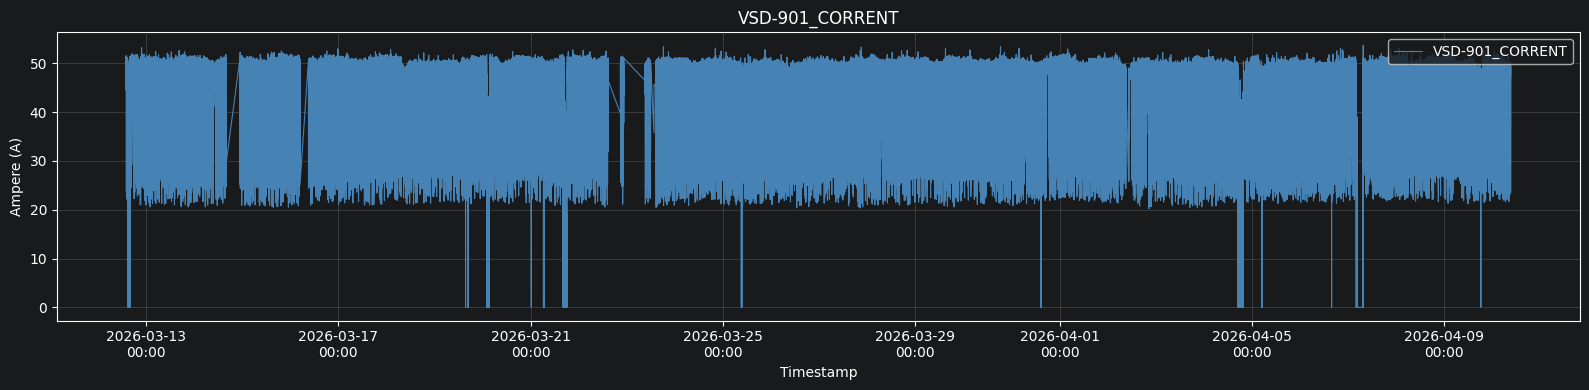

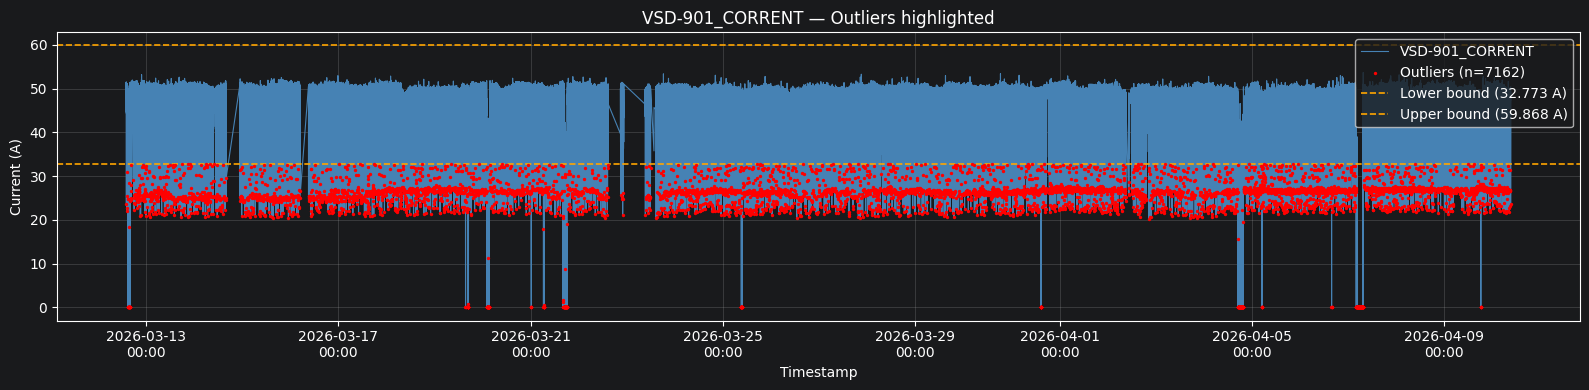

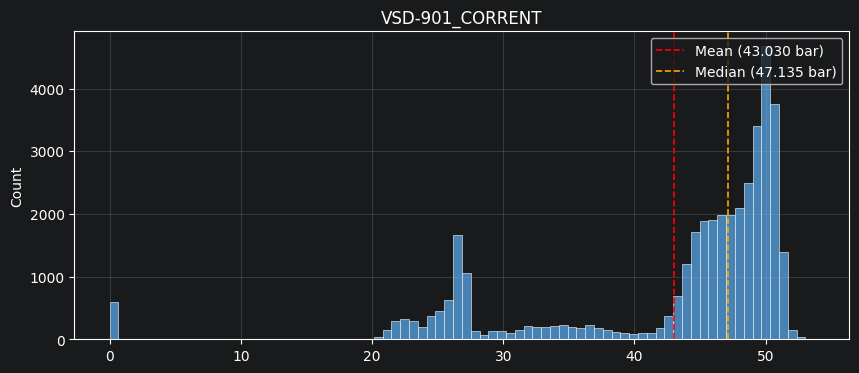

In [16]:
""" Univariate Time Series — VSD-901_CORRENT """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["VSD-901_CORRENT"],
    linewidth=0.8,
    color="steelblue",
    label="VSD-901_CORRENT"
)

ax.set_title("VSD-901_CORRENT")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Ampere (A)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Outlier Highlight — VSD-901_CORRENT """

vsd901_corrent_q1  = df_complete["VSD-901_CORRENT"].quantile(0.25)
vsd901_corrent_q3  = df_complete["VSD-901_CORRENT"].quantile(0.75)
vsd901_corrent_iqr = vsd901_corrent_q3 - vsd901_corrent_q1

vsd901_corrent_lower_bound = vsd901_corrent_q1 - 1.5 * vsd901_corrent_iqr
vsd901_corrent_upper_bound = vsd901_corrent_q3 + 1.5 * vsd901_corrent_iqr

vsd901_corrent_outlier_mask = (df_complete["VSD-901_CORRENT"] < vsd901_corrent_lower_bound) | (df_complete["VSD-901_CORRENT"] > vsd901_corrent_upper_bound)
vsd901_corrent_outliers     = df_complete[vsd901_corrent_outlier_mask]
vsd901_corrent_normal       = df_complete[~vsd901_corrent_outlier_mask]

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["VSD-901_CORRENT"],
    linewidth=0.8,
    color="steelblue",
    label="VSD-901_CORRENT"
)

ax.scatter(
    vsd901_corrent_outliers["timestamp"],
    vsd901_corrent_outliers["VSD-901_CORRENT"],
    color="red",
    s=2,
    zorder=5,
    label=f"Outliers (n={len(vsd901_corrent_outliers)})"
)

ax.axhline(
    y=vsd901_corrent_lower_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Lower bound ({vsd901_corrent_lower_bound:.3f} A)"
)

ax.axhline(
    y=vsd901_corrent_upper_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Upper bound ({vsd901_corrent_upper_bound:.3f} A)"
)

ax.set_title("VSD-901_CORRENT — Outliers highlighted")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Current (A)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Distribution — VSD-901_CORRENT  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["VSD-901_CORRENT"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["VSD-901_CORRENT"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['VSD-901_CORRENT'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["VSD-901_CORRENT"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['VSD-901_CORRENT'].median():.3f} bar)"
)

ax.set_title("VSD-901_CORRENT")
ax.set_ylabel("Ampere (A)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)


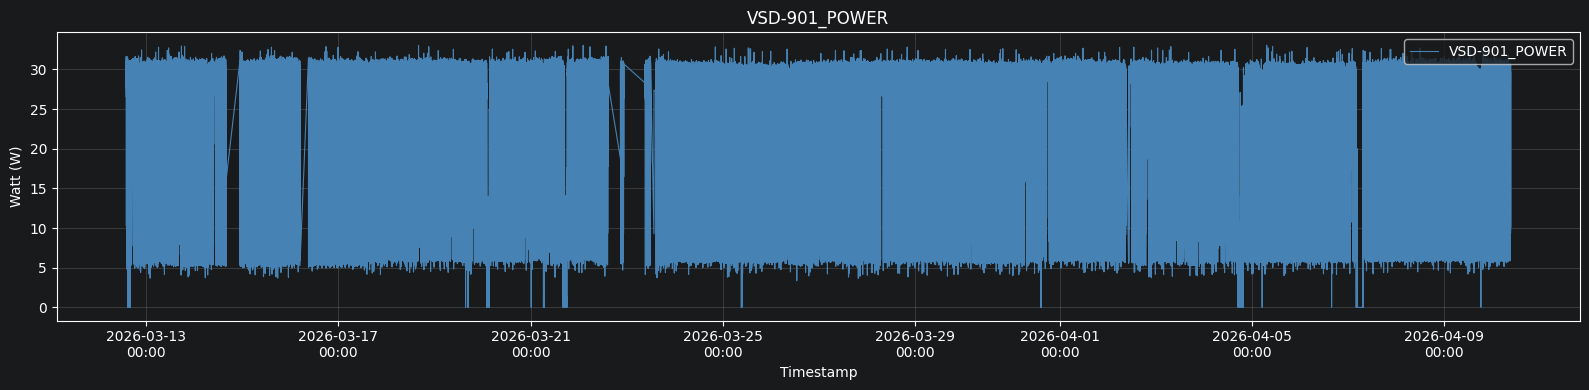

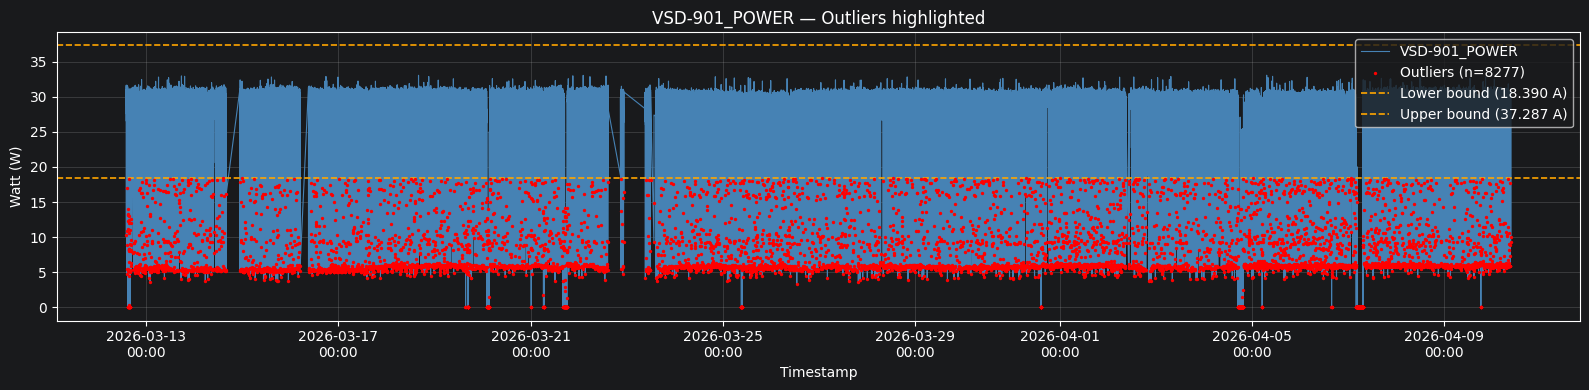

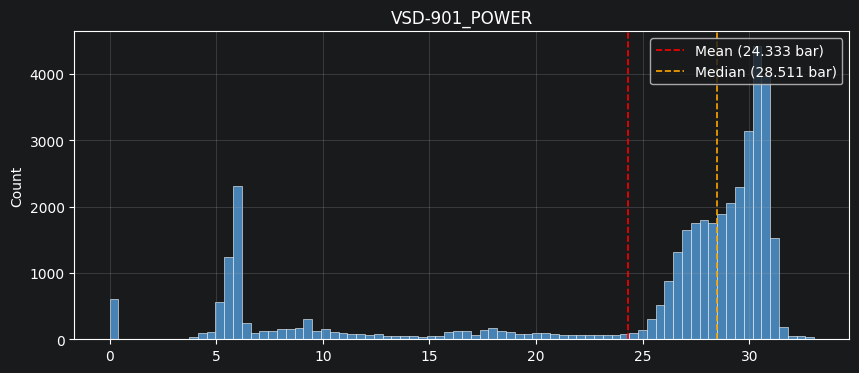

In [17]:
""" Univariate Time Series — VSD-901_POWER """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["VSD-901_POWER"],
    linewidth=0.8,
    color="steelblue",
    label="VSD-901_POWER"
)

ax.set_title("VSD-901_POWER")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Watt (W)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Outlier Highlight — VSD-901_POWER """

vsd901_power_q1  = df_complete["VSD-901_POWER"].quantile(0.25)
vsd901_power_q3  = df_complete["VSD-901_POWER"].quantile(0.75)
vsd901_power_iqr = vsd901_power_q3 - vsd901_power_q1

vsd901_power_lower_bound = vsd901_power_q1 - 1.5 * vsd901_power_iqr
vsd901_power_upper_bound = vsd901_power_q3 + 1.5 * vsd901_power_iqr

vsd901_power_outlier_mask = (df_complete["VSD-901_POWER"] < vsd901_power_lower_bound) | (df_complete["VSD-901_POWER"] > vsd901_power_upper_bound)
vsd901_power_outliers     = df_complete[vsd901_power_outlier_mask]
vsd901_power_normal       = df_complete[~vsd901_power_outlier_mask]

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["VSD-901_POWER"],
    linewidth=0.8,
    color="steelblue",
    label="VSD-901_POWER"
)

ax.scatter(
    vsd901_power_outliers["timestamp"],
    vsd901_power_outliers["VSD-901_POWER"],
    color="red",
    s=2,
    zorder=5,
    label=f"Outliers (n={len(vsd901_power_outliers)})"
)

ax.axhline(
    y=vsd901_power_lower_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Lower bound ({vsd901_power_lower_bound:.3f} A)"
)

ax.axhline(
    y=vsd901_power_upper_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Upper bound ({vsd901_power_upper_bound:.3f} A)"
)

ax.set_title("VSD-901_POWER — Outliers highlighted")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Watt (W)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Distribution — VSD-901_POWER  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["VSD-901_POWER"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["VSD-901_POWER"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['VSD-901_POWER'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["VSD-901_POWER"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['VSD-901_POWER'].median():.3f} bar)"
)

ax.set_title("VSD-901_POWER")
ax.set_ylabel("Watt (W)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

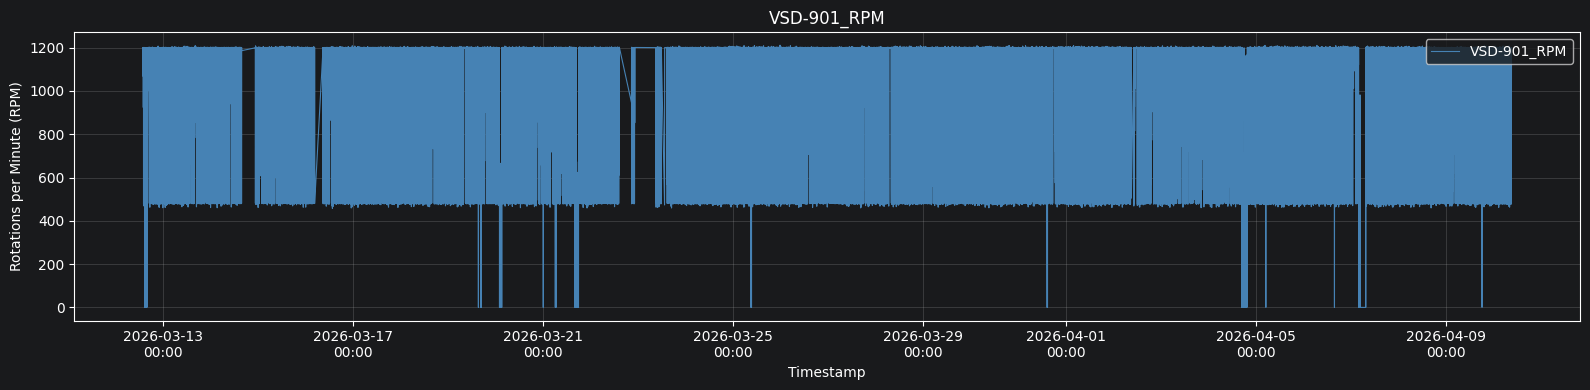

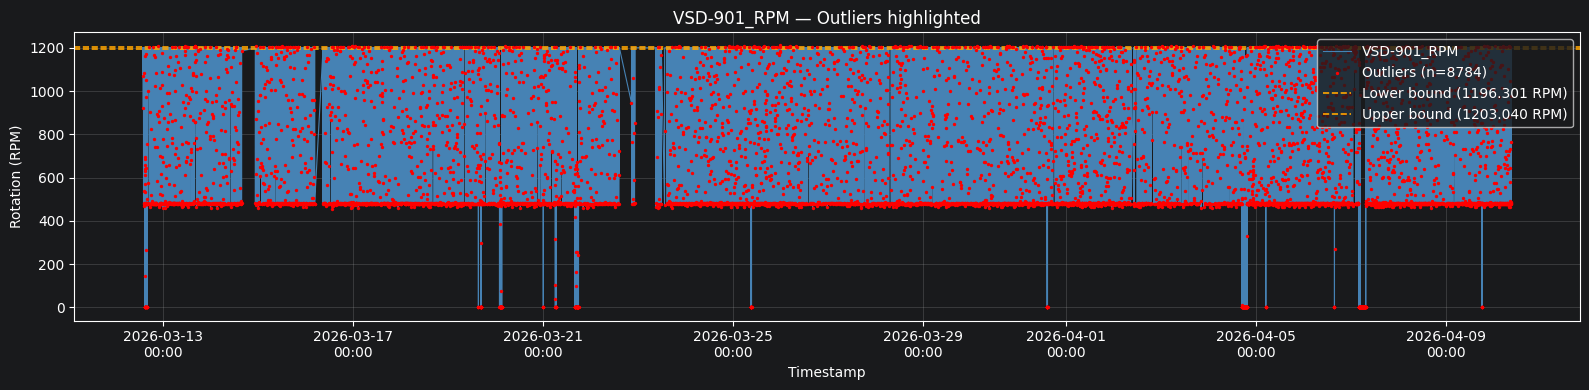

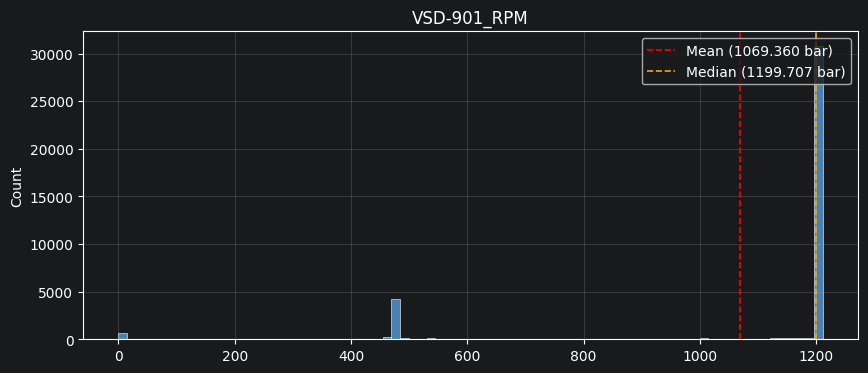

In [18]:
""" Univariate Time Series — VSD-901_RPM """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["VSD-901_RPM"],
    linewidth=0.8,
    color="steelblue",
    label="VSD-901_RPM"
)

ax.set_title("VSD-901_RPM")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Rotations per Minute (RPM)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Outlier Highlight — VSD-901_RPM """

vsd901_rpm_q1  = df_complete["VSD-901_RPM"].quantile(0.25)
vsd901_rpm_q3  = df_complete["VSD-901_RPM"].quantile(0.75)
vsd901_rpm_iqr = vsd901_rpm_q3 - vsd901_rpm_q1

vsd901_rpm_lower_bound = vsd901_rpm_q1 - 1.5 * vsd901_rpm_iqr
vsd901_rpm_upper_bound = vsd901_rpm_q3 + 1.5 * vsd901_rpm_iqr

vsd901_rpm_outlier_mask = (df_complete["VSD-901_RPM"] < vsd901_rpm_lower_bound) | (df_complete["VSD-901_RPM"] > vsd901_rpm_upper_bound)
vsd901_rpm_outliers     = df_complete[vsd901_rpm_outlier_mask]
vsd901_rpm_normal       = df_complete[~vsd901_rpm_outlier_mask]

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["VSD-901_RPM"],
    linewidth=0.8,
    color="steelblue",
    label="VSD-901_RPM"
)

ax.scatter(
    vsd901_rpm_outliers["timestamp"],
    vsd901_rpm_outliers["VSD-901_RPM"],
    color="red",
    s=2,
    zorder=5,
    label=f"Outliers (n={len(vsd901_rpm_outliers)})"
)

ax.axhline(
    y=vsd901_rpm_lower_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Lower bound ({vsd901_rpm_lower_bound:.3f} RPM)"
)

ax.axhline(
    y=vsd901_rpm_upper_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Upper bound ({vsd901_rpm_upper_bound:.3f} RPM)"
)

ax.set_title("VSD-901_RPM — Outliers highlighted")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Rotation (RPM)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Distribution — VSD-901_RPM  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["VSD-901_RPM"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["VSD-901_RPM"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['VSD-901_RPM'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["VSD-901_RPM"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['VSD-901_RPM'].median():.3f} bar)"
)

ax.set_title("VSD-901_RPM")
ax.set_ylabel("Rotations per Minute (RPM)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)


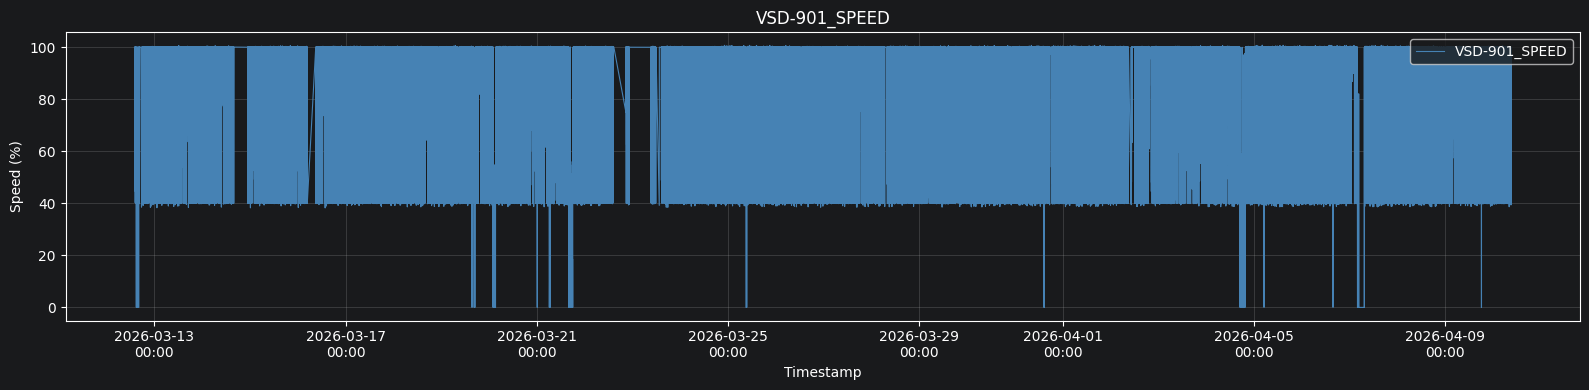

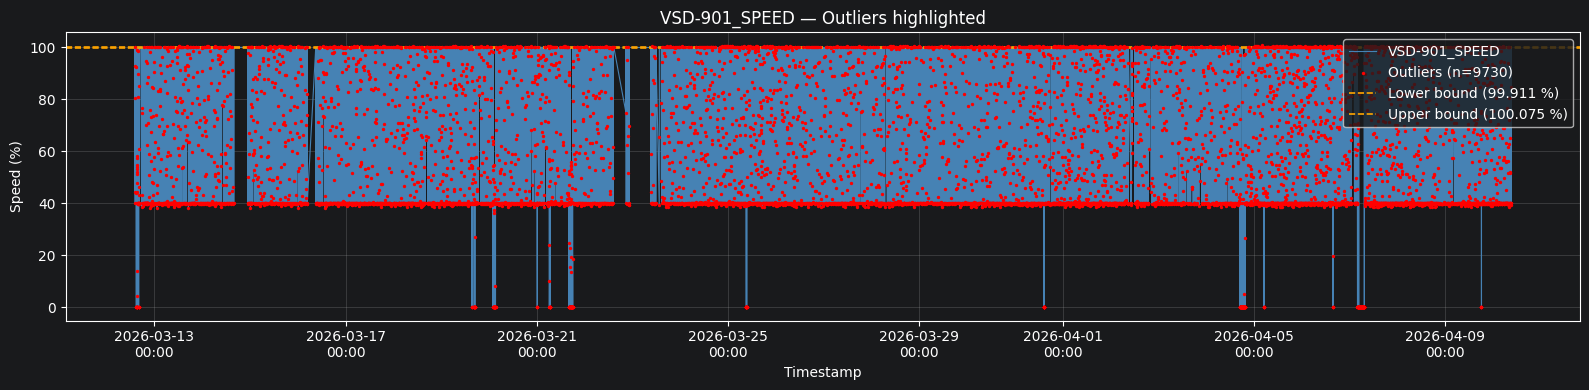

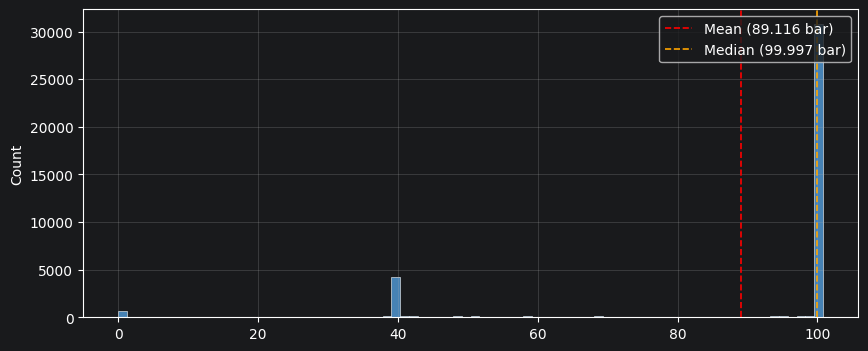

In [19]:
""" Univariate Time Series — VSD-901_SPEED """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["VSD-901_SPEED"],
    linewidth=0.8,
    color="steelblue",
    label="VSD-901_SPEED"
)

ax.set_title("VSD-901_SPEED")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Speed (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Outlier Highlight — VSD-901_SPEED """

vsd901_speed_q1  = df_complete["VSD-901_SPEED"].quantile(0.25)
vsd901_speed_q3  = df_complete["VSD-901_SPEED"].quantile(0.75)
vsd901_speed_iqr = vsd901_speed_q3 - vsd901_speed_q1

vsd901_speed_lower_bound = vsd901_speed_q1 - 1.5 * vsd901_speed_iqr
vsd901_speed_upper_bound = vsd901_speed_q3 + 1.5 * vsd901_speed_iqr

vsd901_speed_outlier_mask = (df_complete["VSD-901_SPEED"] < vsd901_speed_lower_bound) | (df_complete["VSD-901_SPEED"] > vsd901_speed_upper_bound)
vsd901_speed_outliers     = df_complete[vsd901_speed_outlier_mask]
vsd901_speed_normal       = df_complete[~vsd901_speed_outlier_mask]

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["VSD-901_SPEED"],
    linewidth=0.8,
    color="steelblue",
    label="VSD-901_SPEED"
)

ax.scatter(
    vsd901_speed_outliers["timestamp"],
    vsd901_speed_outliers["VSD-901_SPEED"],
    color="red",
    s=2,
    zorder=5,
    label=f"Outliers (n={len(vsd901_speed_outliers)})"
)

ax.axhline(
    y=vsd901_speed_lower_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Lower bound ({vsd901_speed_lower_bound:.3f} %)"
)

ax.axhline(
    y=vsd901_speed_upper_bound,
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Upper bound ({vsd901_speed_upper_bound:.3f} %)"
)

ax.set_title("VSD-901_SPEED — Outliers highlighted")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Speed (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

""" Univariate Distribution — VSD-901_SPEED  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["VSD-901_SPEED"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["VSD-901_SPEED"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['VSD-901_SPEED'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["VSD-901_SPEED"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['VSD-901_SPEED'].median():.3f} bar)"
)

ax.set_ylabel("Speed (%)")
ax.set_ylabel("Rotations per Minute (RPM)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)


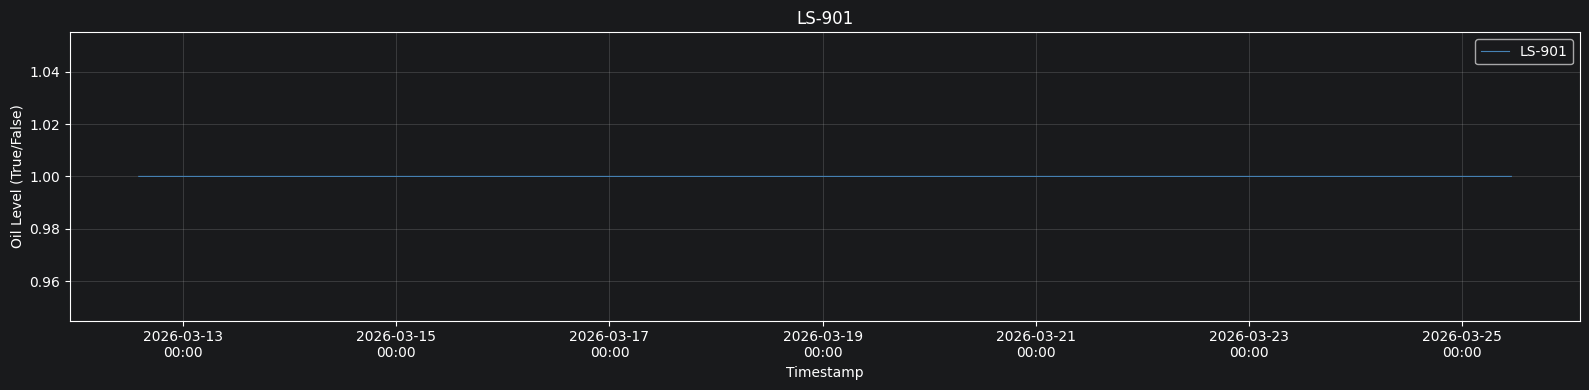

In [20]:
""" Univariate Time Series — LS-901 """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["LS-901"],
    linewidth=0.8,
    color="steelblue",
    label="LS-901"
)

ax.set_title("LS-901")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Oil Level (True/False)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


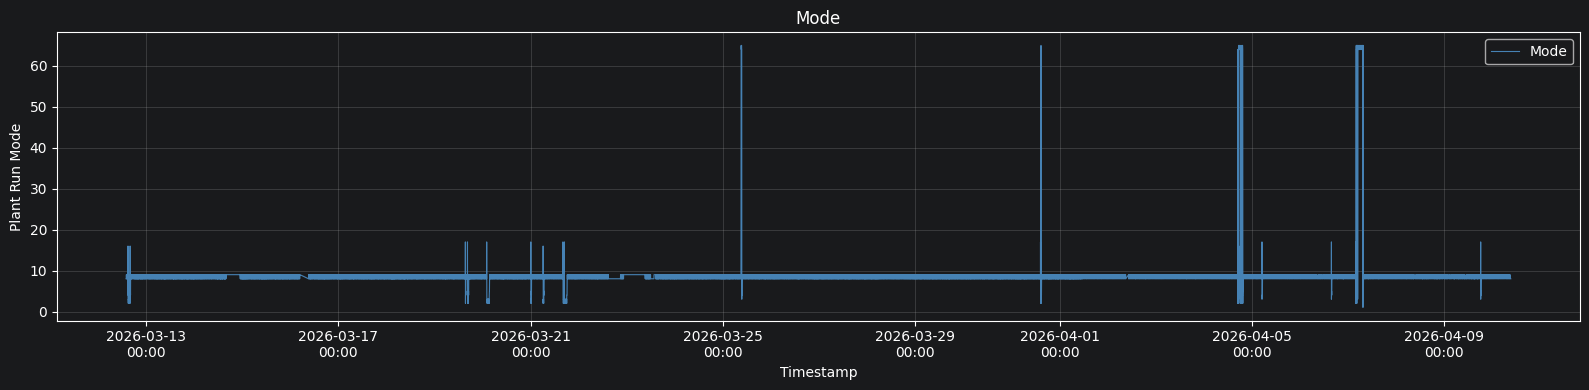

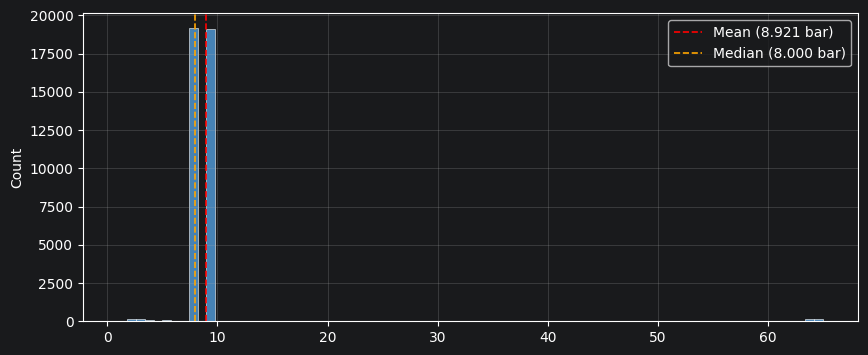

In [21]:
""" Univariate Time Series — Mode """

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    df_complete["timestamp"],
    df_complete["Mode"],
    linewidth=0.8,
    color="steelblue",
    label="Mode"
)

ax.set_title("Mode")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Plant Run Mode")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


""" Univariate Distribution — Mode  """
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df_complete["Mode"].dropna(),
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

ax.axvline(
    x=df_complete["Mode"].mean(),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label=f"Mean ({df_complete['Mode'].mean():.3f} bar)"
)

ax.axvline(
    x=df_complete["Mode"].median(),
    color="orange",
    linewidth=1.2,
    linestyle="--",
    label=f"Median ({df_complete['Mode'].median():.3f} bar)"
)

ax.set_ylabel("Plant Run Mode")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

### Exploratory Zooming

In [22]:
""" Identify gaps larger than 30 minutes in VSD-901_CORRENT timestamps """

vsd901_corrent_time_diff = df_complete["timestamp"].diff()

vsd901_corrent_gap_mask = vsd901_corrent_time_diff > pd.Timedelta(minutes=30)

vsd901_corrent_gaps = df_complete[vsd901_corrent_gap_mask][["timestamp"]].copy()
vsd901_corrent_gaps["gap_start"] = df_complete["timestamp"].shift(1)[vsd901_corrent_gap_mask]
vsd901_corrent_gaps["gap_end"]   = vsd901_corrent_gaps["timestamp"]
vsd901_corrent_gaps["gap_duration_minutes"] = vsd901_corrent_time_diff[vsd901_corrent_gap_mask].dt.total_seconds() / 60

vsd901_corrent_gaps = vsd901_corrent_gaps[["gap_start", "gap_end", "gap_duration_minutes"]].reset_index(drop=True)

print(f"Number of gaps larger than 30 minutes: {len(vsd901_corrent_gaps)}")

vsd901_corrent_gaps

Number of gaps larger than 30 minutes: 7


,gap_start,gap_end,gap_duration_minutes
0,2026-03-14 15:57:00,2026-03-14 22:50:00,413.0
1,2026-03-16 04:48:00,2026-03-16 09:02:00,254.0
2,2026-03-22 14:44:00,2026-03-22 20:47:00,363.0
3,2026-03-22 22:28:00,2026-03-23 09:09:00,641.0
4,2026-03-23 11:52:00,2026-03-23 13:31:00,99.0
5,2026-03-23 13:34:00,2026-03-23 14:22:00,48.0
6,2026-04-02 09:06:00,2026-04-02 10:28:00,82.0


#### Gaps

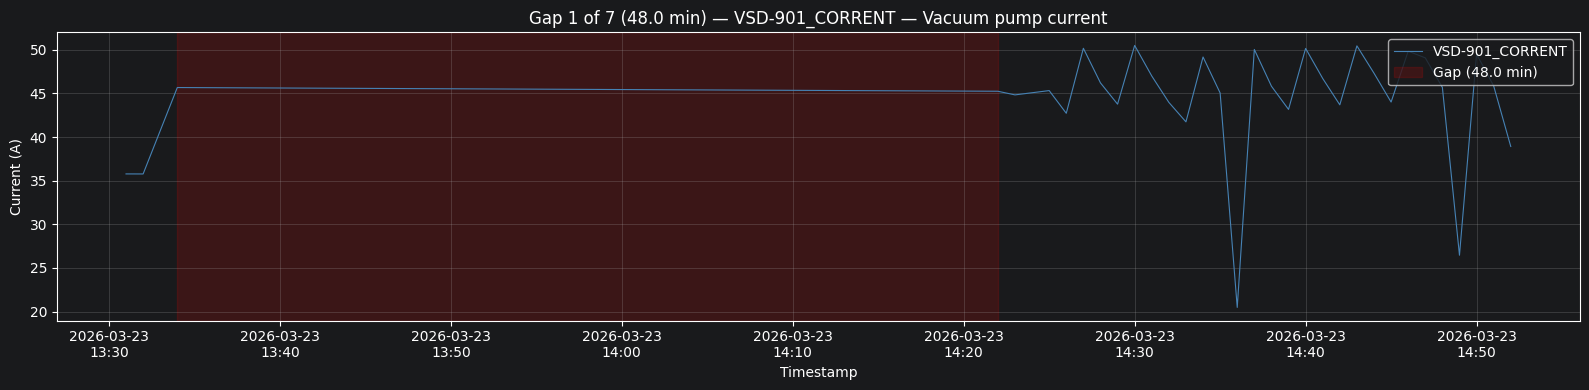

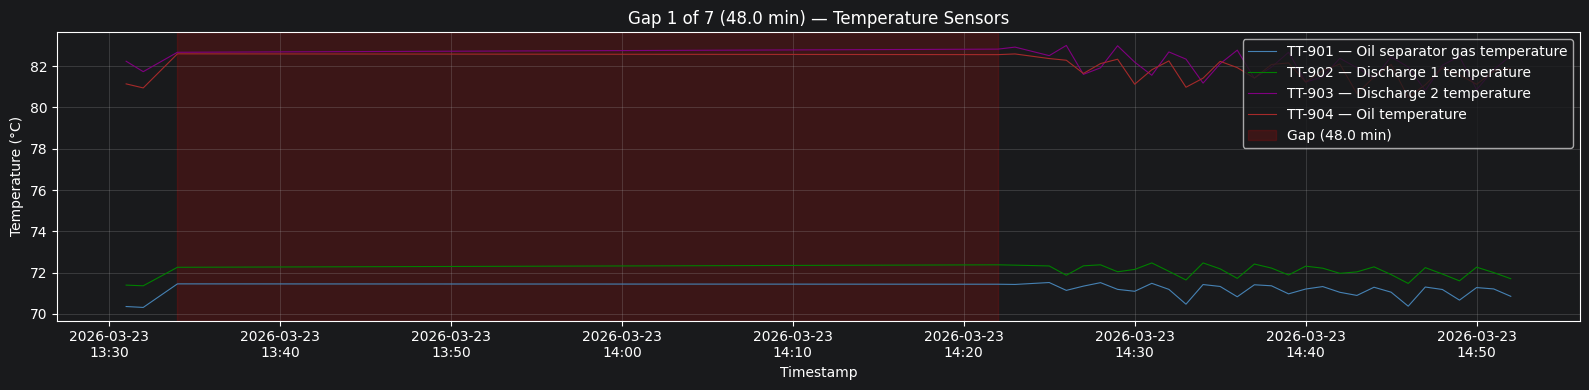

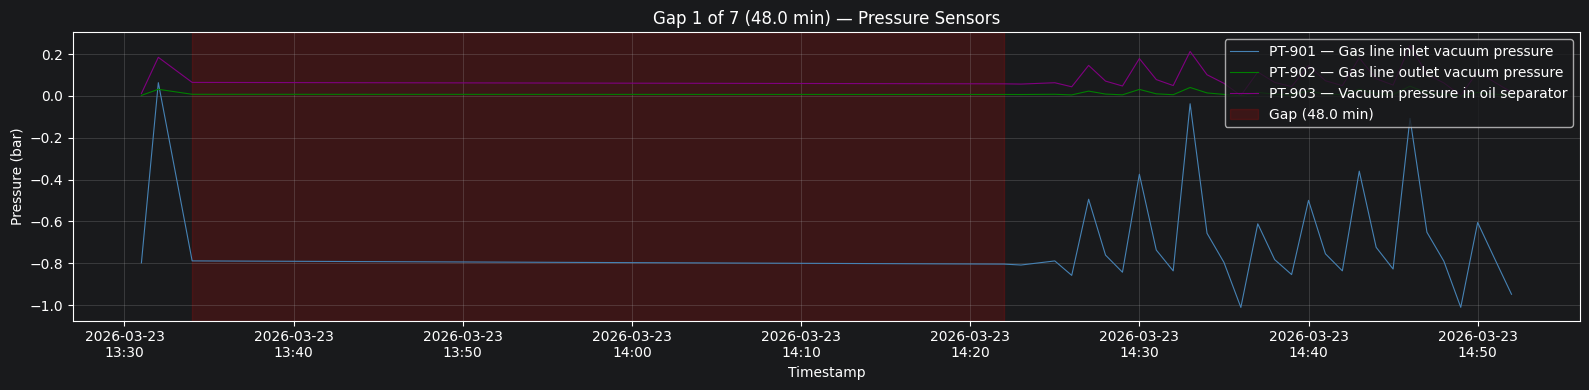

--------------------------------------------------------------------------------


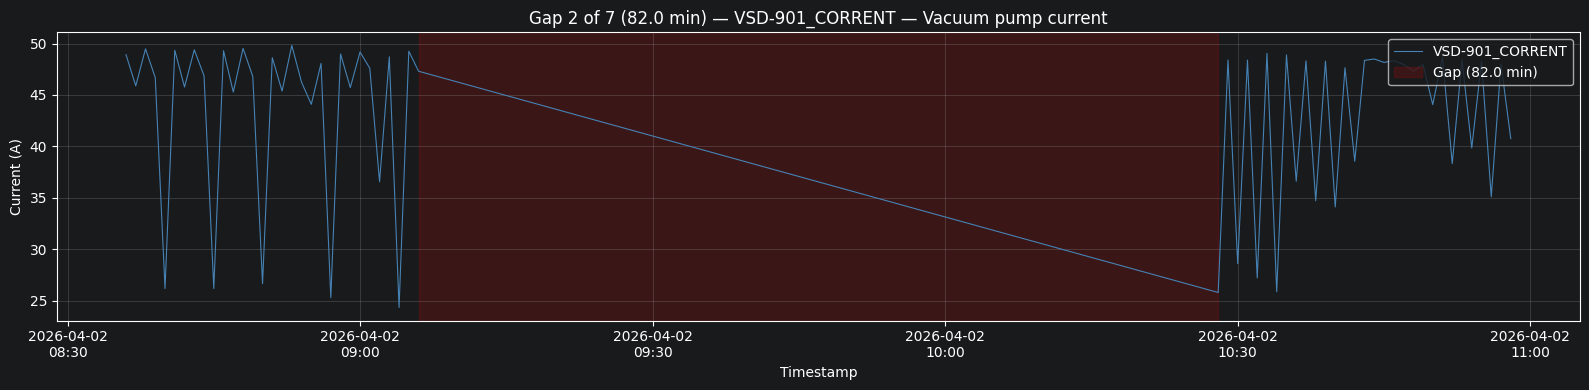

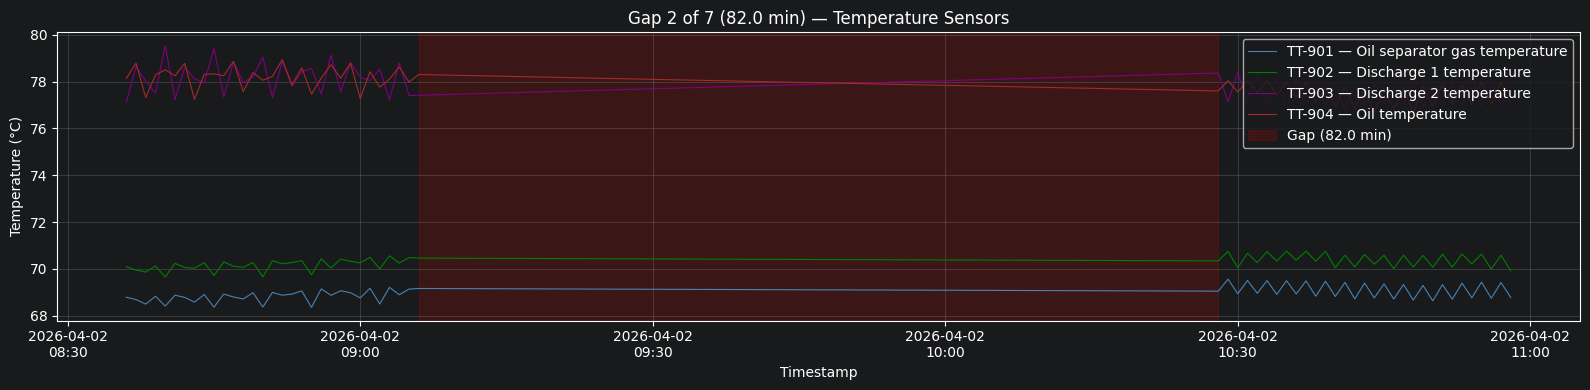

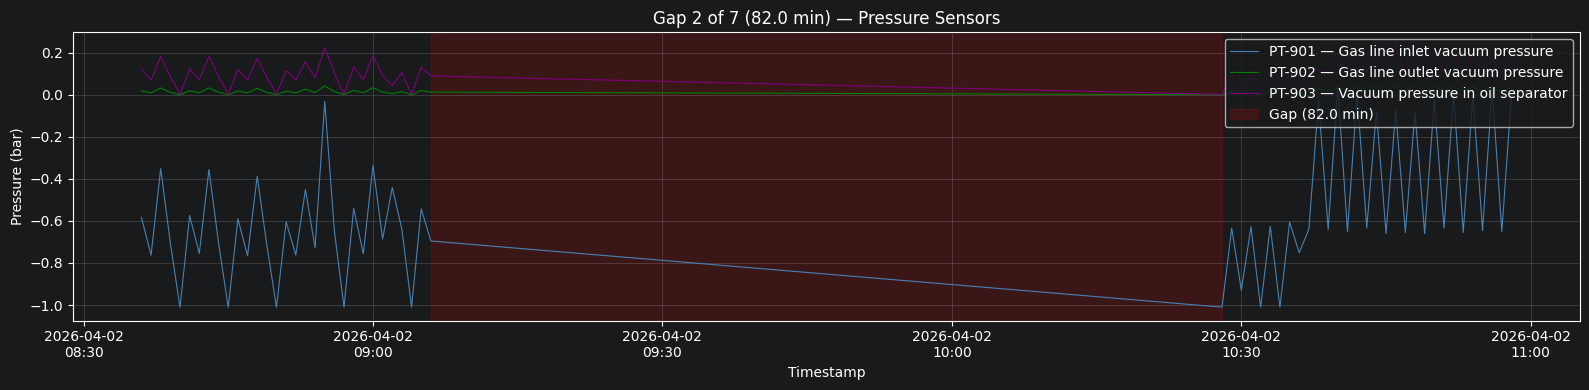

--------------------------------------------------------------------------------


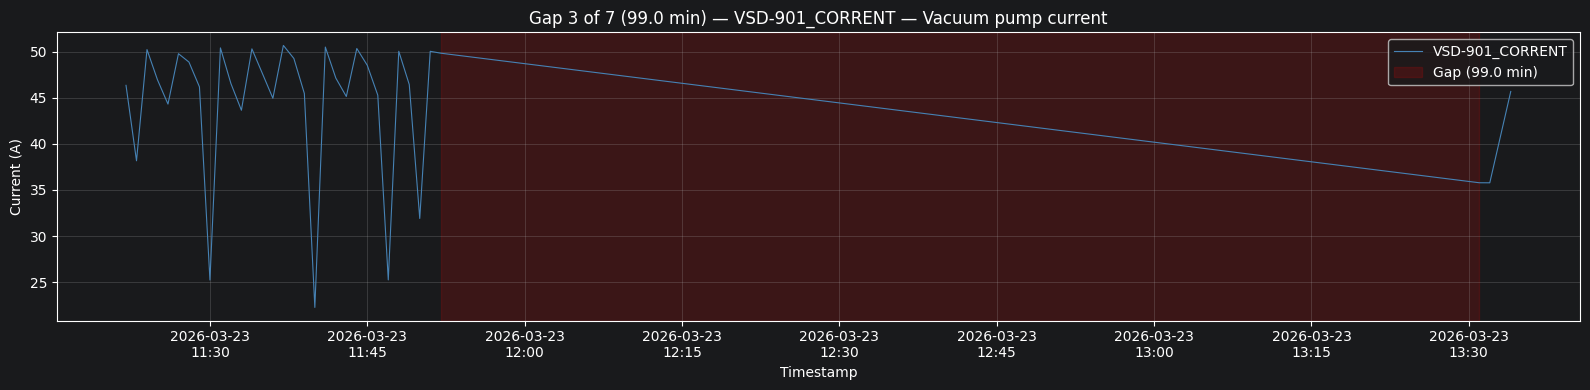

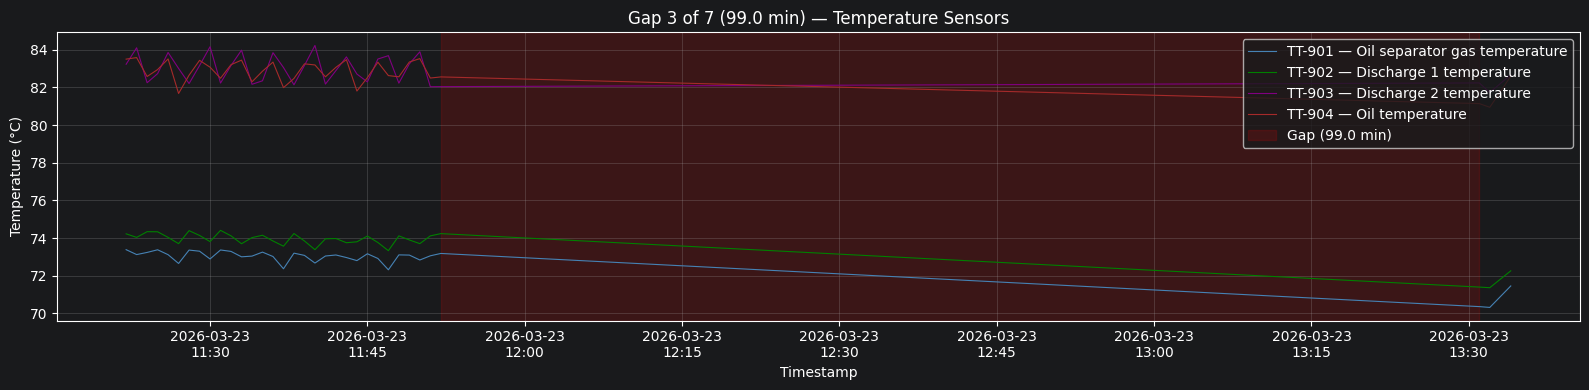

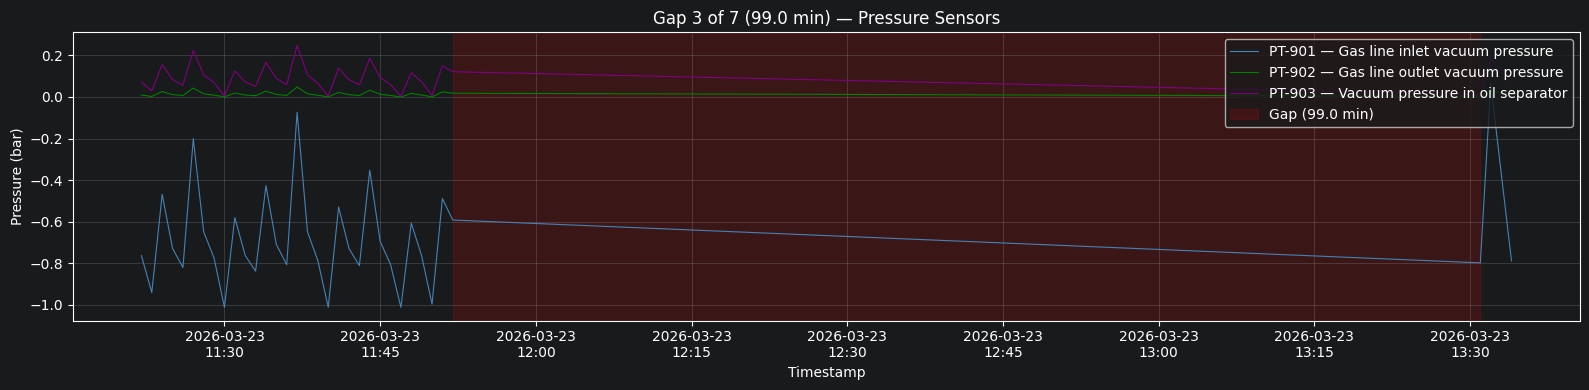

--------------------------------------------------------------------------------


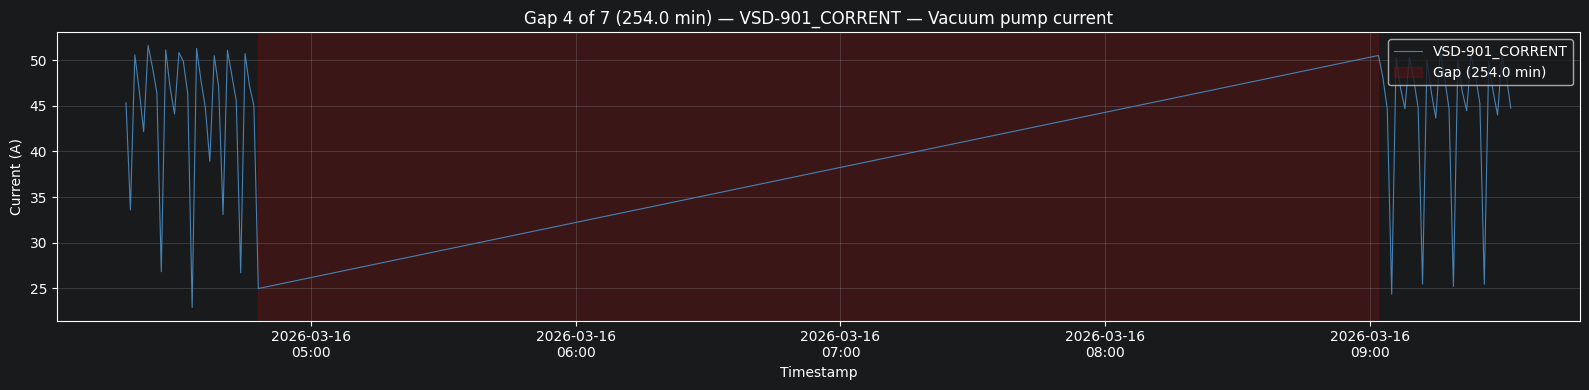

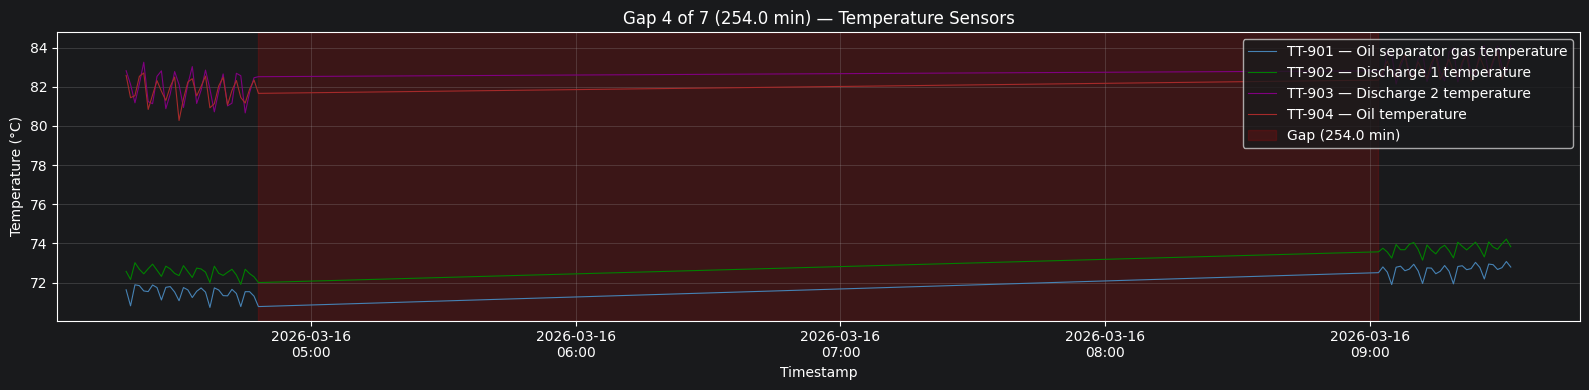

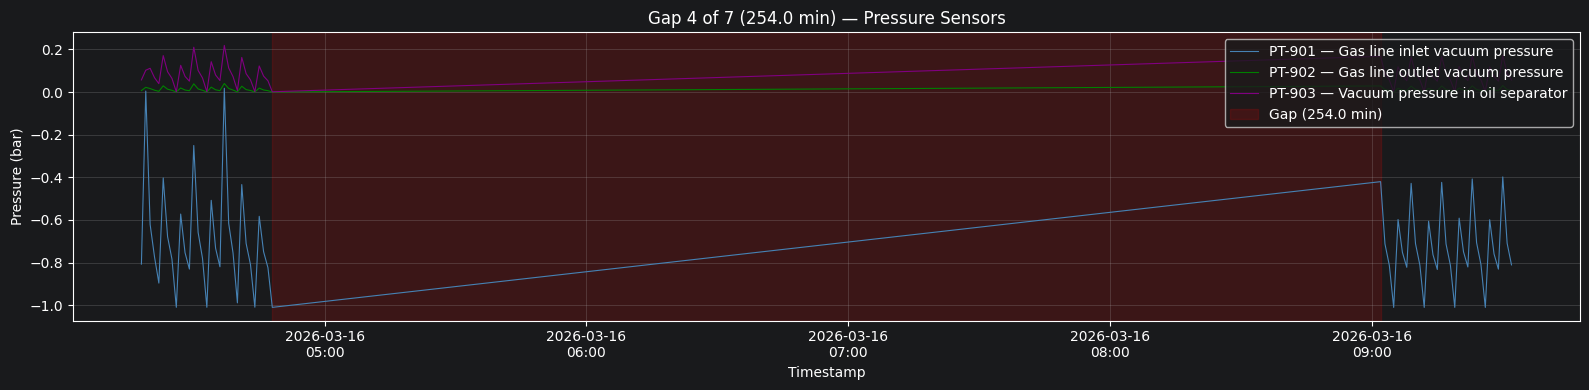

--------------------------------------------------------------------------------


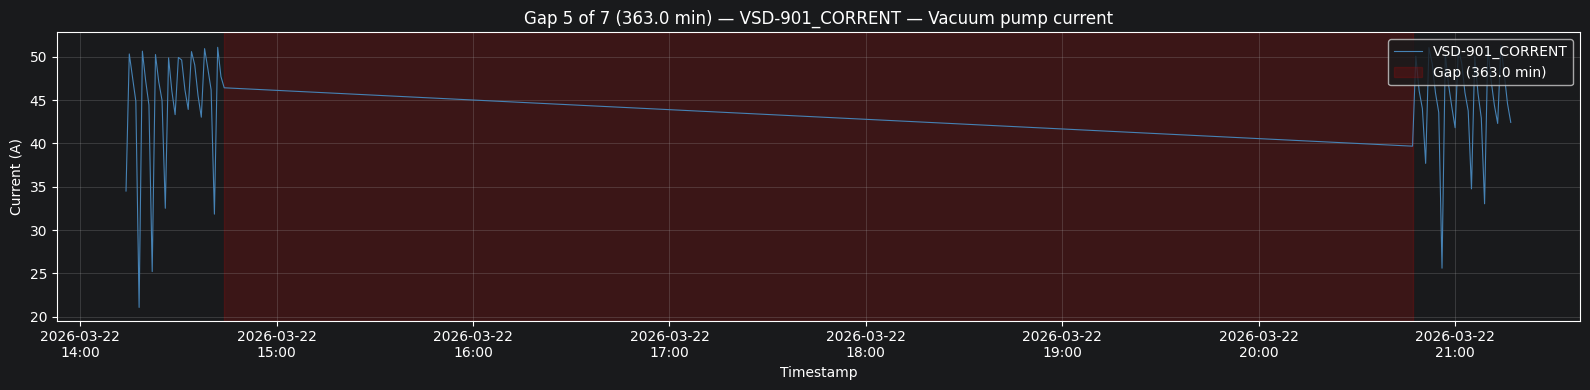

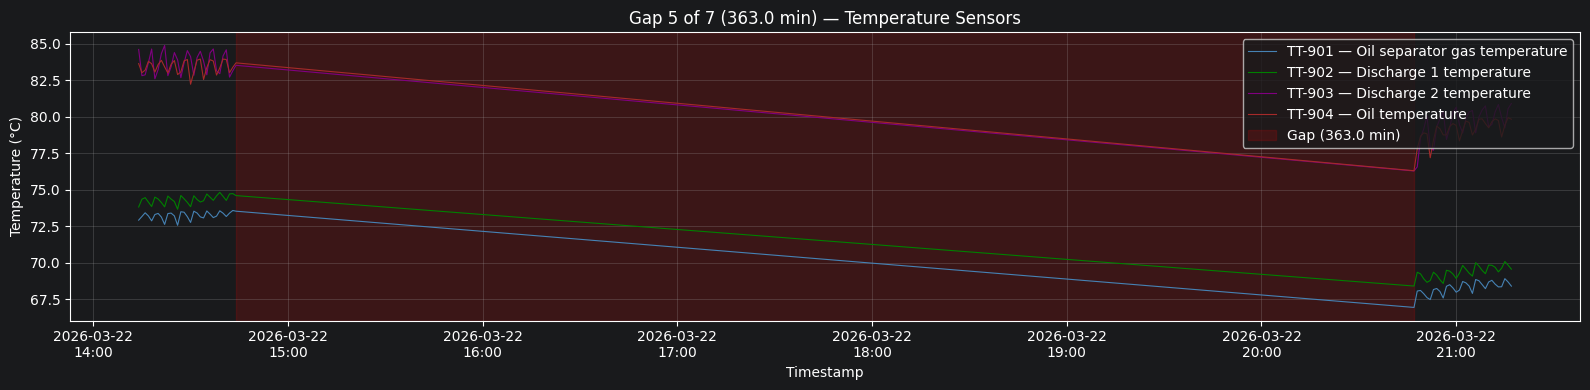

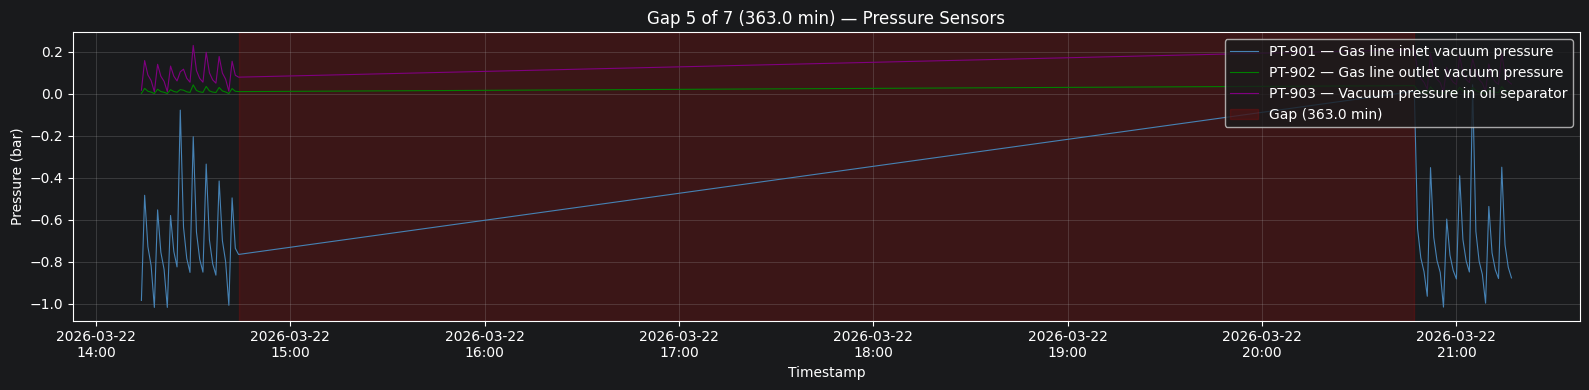

--------------------------------------------------------------------------------


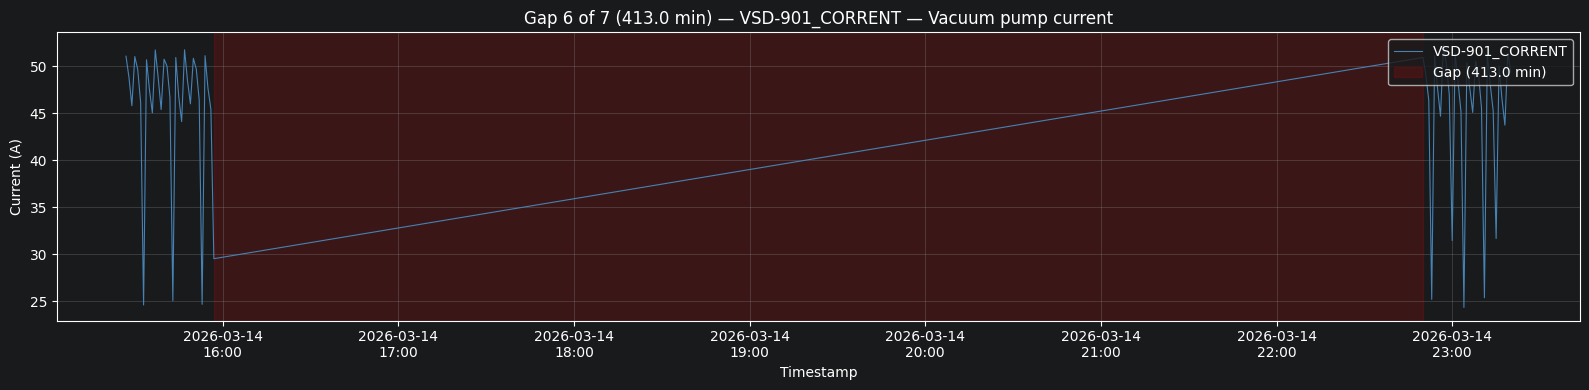

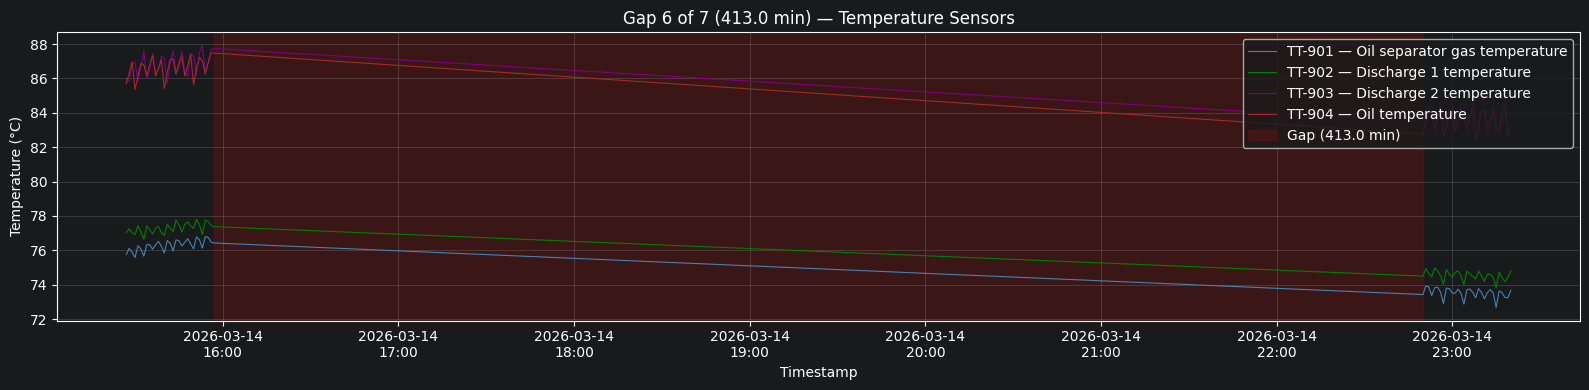

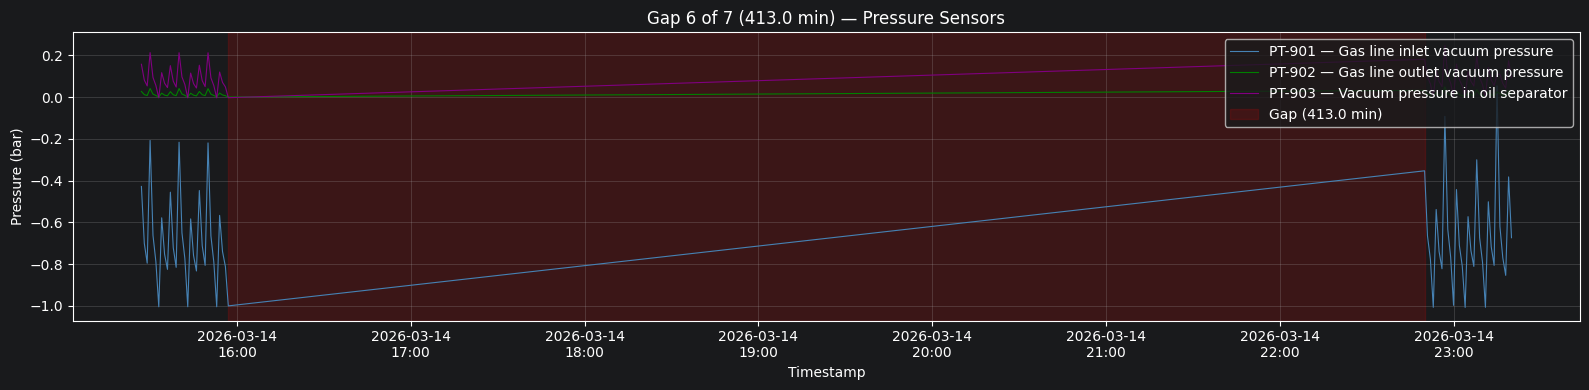

--------------------------------------------------------------------------------


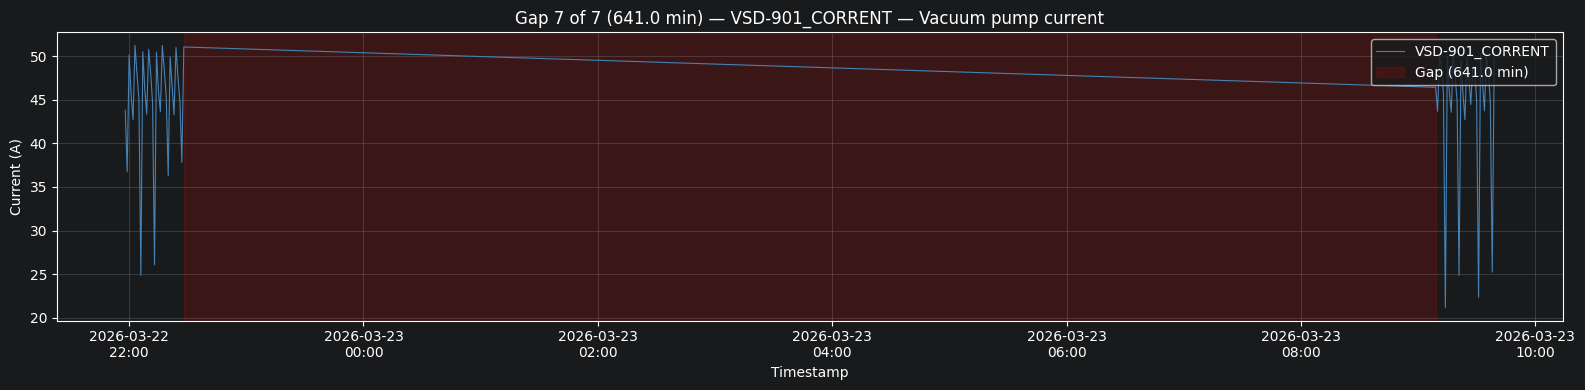

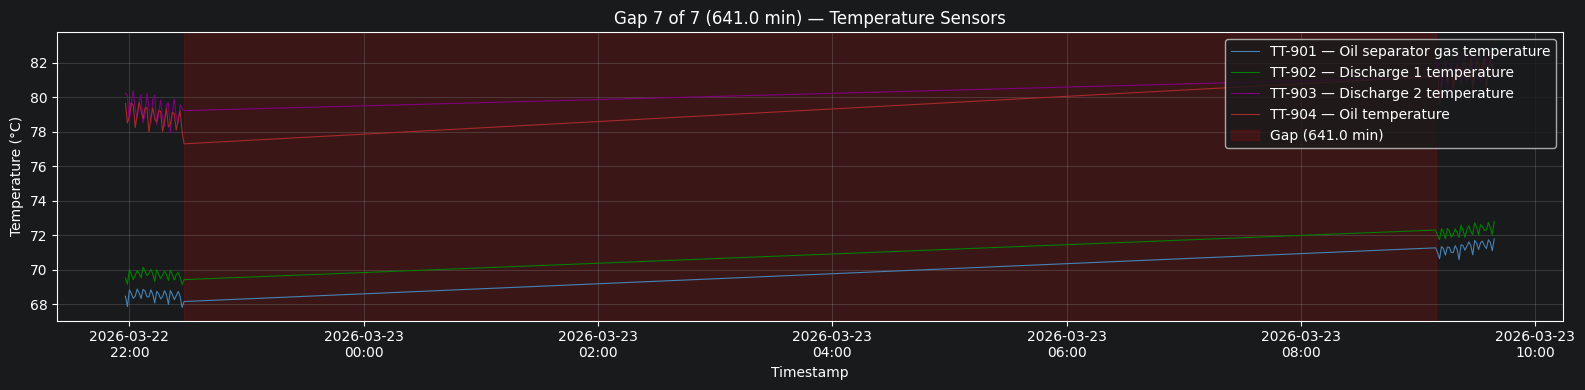

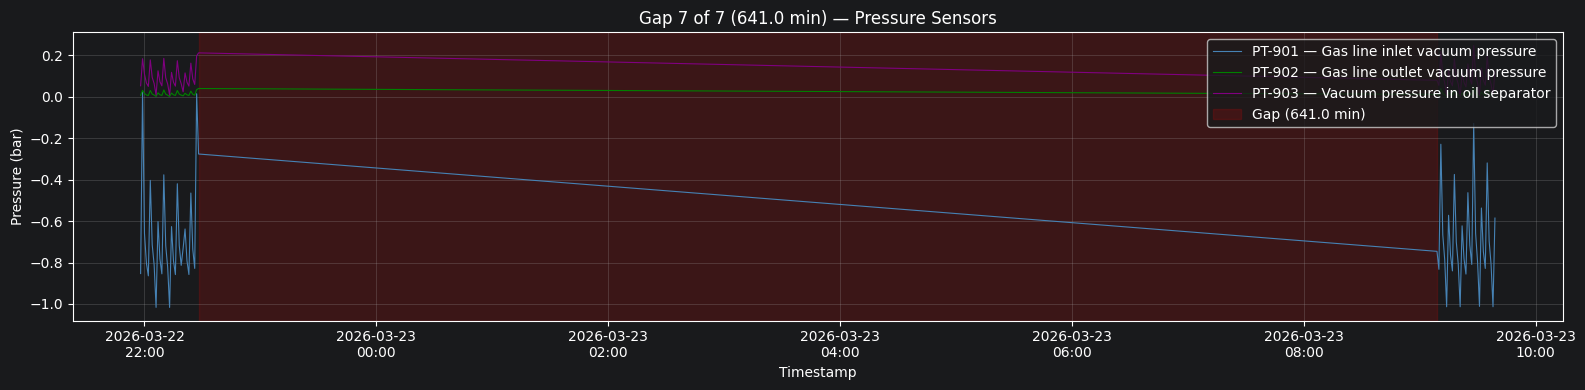

--------------------------------------------------------------------------------


In [23]:
""" Plot all identified gaps ordered from smallest to biggest — VSD-901_CORRENT, Temperature and Pressure sensors """

vsd901_corrent_gaps_sorted = vsd901_corrent_gaps.sort_values("gap_duration_minutes").reset_index(drop=True)

context_before = pd.Timedelta(minutes=30)
context_after  = pd.Timedelta(minutes=30)

for idx, gap in vsd901_corrent_gaps_sorted.iterrows():

    gap_start         = gap["gap_start"]
    gap_end           = gap["gap_end"]
    gap_duration_min  = gap["gap_duration_minutes"]

    window_start = gap_start - context_before
    window_end   = gap_end   + context_after

    df_gap_window = df_complete[
        (df_complete["timestamp"] >= window_start) &
        (df_complete["timestamp"] <= window_end)
    ]

    # --------------------------------------------------------
    # PLOT 1 — VSD-901_CORRENT
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(16, 4))

    ax.plot(
        df_gap_window["timestamp"],
        df_gap_window["VSD-901_CORRENT"],
        linewidth=0.8,
        color="steelblue",
        label="VSD-901_CORRENT"
    )

    ax.axvspan(
        gap_start,
        gap_end,
        color="red",
        alpha=0.15,
        label=f"Gap ({gap_duration_min:.1f} min)"
    )

    ax.set_title(f"Gap {idx+1} of {len(vsd901_corrent_gaps_sorted)} ({gap_duration_min:.1f} min) — VSD-901_CORRENT — Vacuum pump current")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Current (A)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # PLOT 2 — TEMPERATURE SENSORS
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(16, 4))

    ax.plot(
        df_gap_window["timestamp"],
        df_gap_window["TT-901"],
        linewidth=0.8,
        color="steelblue",
        label="TT-901 — Oil separator gas temperature"
    )

    ax.plot(
        df_gap_window["timestamp"],
        df_gap_window["TT-902"],
        linewidth=0.8,
        color="green",
        label="TT-902 — Discharge 1 temperature"
    )

    ax.plot(
        df_gap_window["timestamp"],
        df_gap_window["TT-903"],
        linewidth=0.8,
        color="purple",
        label="TT-903 — Discharge 2 temperature"
    )

    ax.plot(
        df_gap_window["timestamp"],
        df_gap_window["TT-904"],
        linewidth=0.8,
        color="brown",
        label="TT-904 — Oil temperature"
    )

    ax.axvspan(
        gap_start,
        gap_end,
        color="red",
        alpha=0.15,
        label=f"Gap ({gap_duration_min:.1f} min)"
    )

    ax.set_title(f"Gap {idx+1} of {len(vsd901_corrent_gaps_sorted)} ({gap_duration_min:.1f} min) — Temperature Sensors")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Temperature (°C)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # PLOT 3 — PRESSURE SENSORS
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(16, 4))

    ax.plot(
        df_gap_window["timestamp"],
        df_gap_window["PT-901"],
        linewidth=0.8,
        color="steelblue",
        label="PT-901 — Gas line inlet vacuum pressure"
    )

    ax.plot(
        df_gap_window["timestamp"],
        df_gap_window["PT-902"],
        linewidth=0.8,
        color="green",
        label="PT-902 — Gas line outlet vacuum pressure"
    )

    ax.plot(
        df_gap_window["timestamp"],
        df_gap_window["PT-903"],
        linewidth=0.8,
        color="purple",
        label="PT-903 — Vacuum pressure in oil separator"
    )

    ax.axvspan(
        gap_start,
        gap_end,
        color="red",
        alpha=0.15,
        label=f"Gap ({gap_duration_min:.1f} min)"
    )

    ax.set_title(f"Gap {idx+1} of {len(vsd901_corrent_gaps_sorted)} ({gap_duration_min:.1f} min) — Pressure Sensors")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Pressure (bar)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("-" * 80)

## Multivariate Analysis

### Global Correlation Matrix

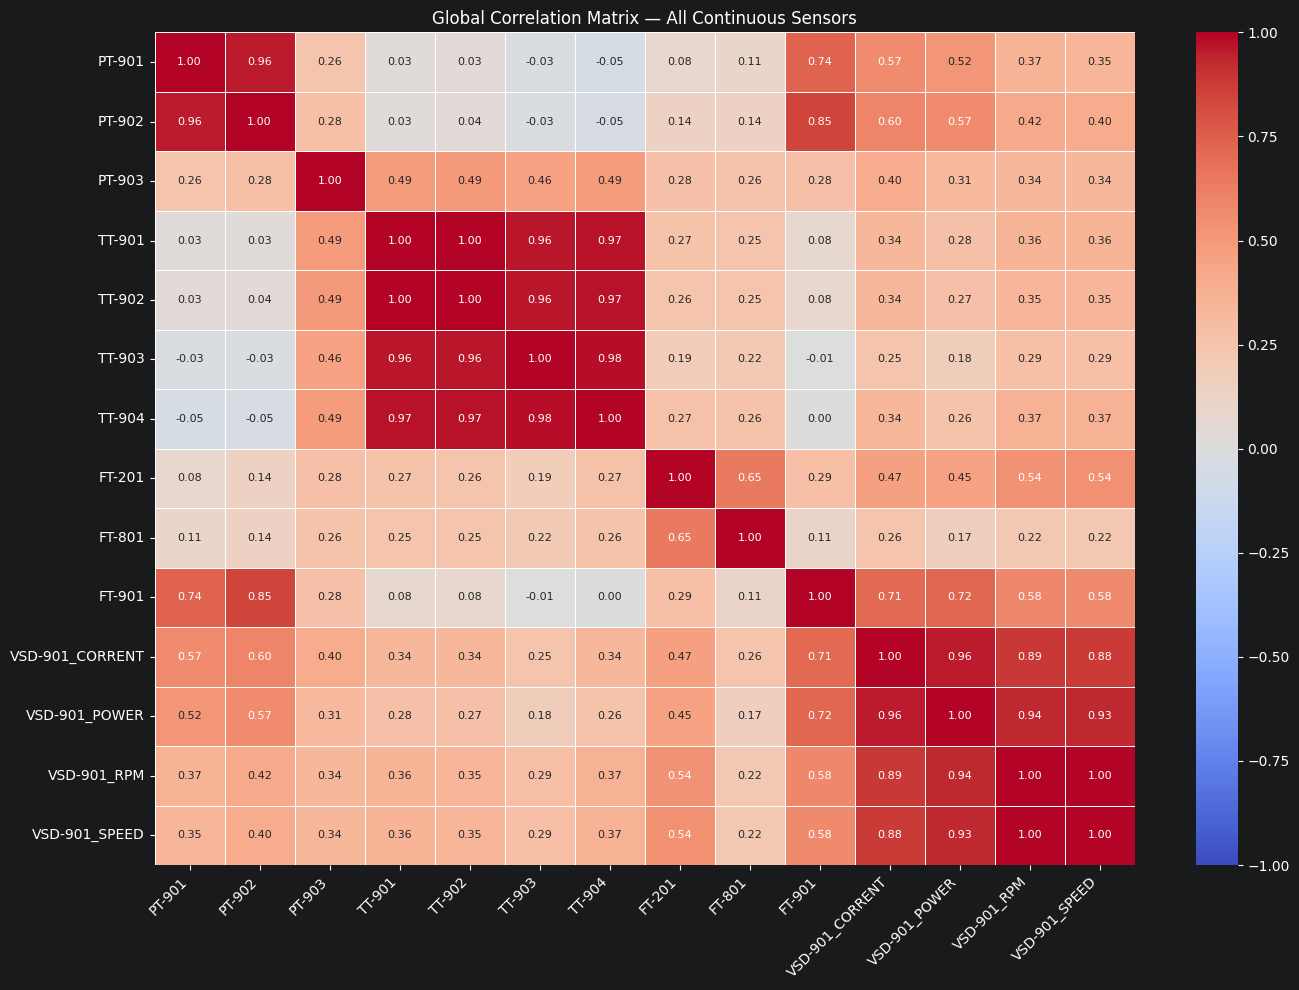

In [24]:
""" Multivariate Analysis — Global Correlation Matrix """

continuous_cols = ["PT-901", "PT-902", "PT-903",
                   "TT-901", "TT-902", "TT-903", "TT-904",
                   "FT-201", "FT-801", "FT-901",
                   "VSD-901_CORRENT", "VSD-901_POWER", "VSD-901_RPM", "VSD-901_SPEED"]

global_correlation_matrix = df_complete[continuous_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    global_correlation_matrix,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 8}
)

ax.set_title("Global Correlation Matrix — All Continuous Sensors")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

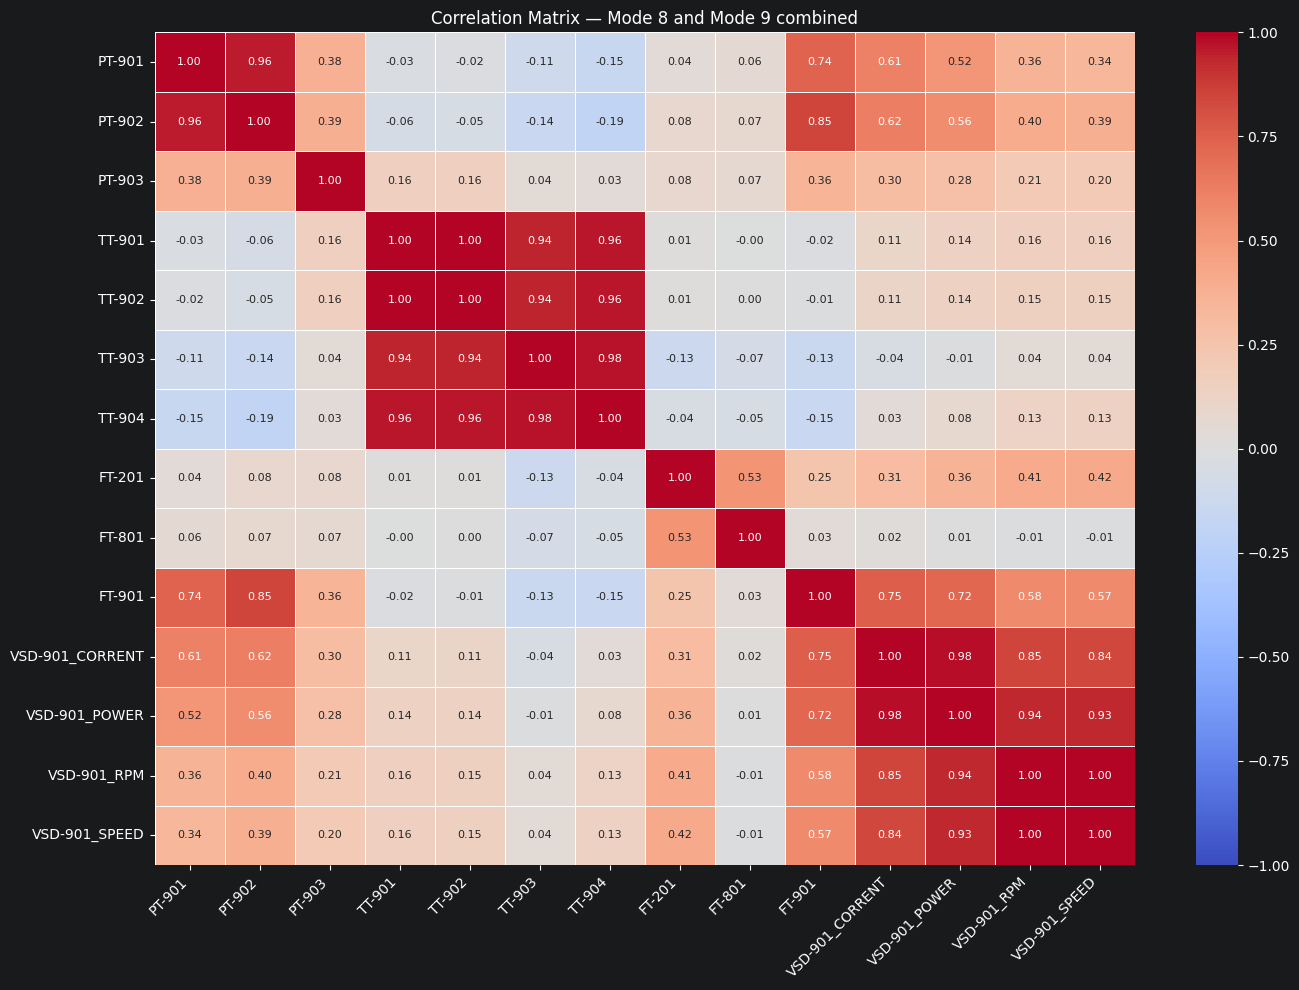

In [25]:
""" Multivariate Analysis — Correlation Matrix for Mode 8 and Mode 9 combined """

df_mode_8_and_9 = df_complete[df_complete["Mode"].isin([8, 9])]

continuous_cols = ["PT-901", "PT-902", "PT-903",
                   "TT-901", "TT-902", "TT-903", "TT-904",
                   "FT-201", "FT-801", "FT-901",
                   "VSD-901_CORRENT", "VSD-901_POWER", "VSD-901_RPM", "VSD-901_SPEED"]

mode_8_and_9_correlation_matrix = df_mode_8_and_9[continuous_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    mode_8_and_9_correlation_matrix,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 8}
)

ax.set_title("Correlation Matrix — Mode 8 and Mode 9 combined")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()